## This code runs the data for females through the pipeline to check whether each organ truly satisfies a power law. 

### 1. Load packages

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats

### 2. Read in data

In [31]:
df = pd.read_csv("kleiber_females.csv")

print(df.shape)
print(df.head())

(231, 132)
  Race   Age  Height  weight    SA  Measured RMR  Mass  weight.1     AT  \
0    C  19.0   1.700  101.41  2.10        1769.0   NaN    101.41  55.10   
1    C  22.0   1.670   83.49  1.91        1643.0   NaN     83.49  39.70   
2    C  22.0   1.610   86.42  1.89        1532.0   NaN     86.42  49.80   
3    C  23.0   1.539   51.60  1.50        1145.0   NaN     51.60   9.35   
4    C  23.0   1.710   59.16  1.66        1535.0   NaN     59.16  16.70   

      SM  ...  AT Mass.1  SM MRI.1  BMC.1  liver mass  heart mass  \
0  24.90  ...       1.56      1.46   0.64        0.15       -0.50   
1  22.70  ...       1.63      1.34   0.56        0.20       -0.62   
2  22.70  ...       1.68      1.31   0.54        0.21       -0.59   
3  20.29  ...       1.52      1.34   0.59        0.22       -0.50   
4  20.50  ...       1.35      1.32   0.61        0.16       -0.70   

   kidney masses  spleen mass  Brain mass  Skin.1  Residual.1  
0          -0.58        -0.75        0.15    0.58        0.

### 3. Sniff Check Columns

In [32]:
df.columns = df.columns.str.strip()

print("Column names:")
for col in df.columns:
    print(col)

Column names:
Race
Age
Height
weight
SA
Measured RMR
Mass
weight.1
AT
SM
Bone
Liver
heart
Kidney
Spleen
Brain
Skin
Residual
AT MR
SM MR
bone MR
liver MR
heart MR
kidney MR
spleen MR
brain MR
skin MR
residual MR
REE-calc
Log Calories
AT.1
SM.1
bone
liver
heart.1
kidney
spleen
brain
skin
residual
Calculated RMR
hidden files
Unnamed: 42
Unnamed: 43
Unnamed: 44
Unnamed: 45
Unnamed: 46
Unnamed: 47
Unnamed: 48
Unnamed: 49
Unnamed: 50
Unnamed: 51
Unnamed: 52
Unnamed: 53
Unnamed: 54
Unnamed: 55
Unnamed: 56
Unnamed: 57
Unnamed: 58
Unnamed: 59
Unnamed: 60
Unnamed: 61
Unnamed: 62
Unnamed: 63
REE
REE C
REE-calc.1
Height.1
Age.1
weight.2
REE/BW
delta pred - meas
V
SA/V
Organ EE
AT.2
SM.2
bone.1
liver.1
heart.2
kidney.1
spleen.1
brain.1
skin.1
residual.1
REE-calc.2
Unnamed: 86
Extra
Msk
Code
BMC
Unnamed: 91
FFM
%FM
%AT
ATFM
AT Mass
Total AT volume (cm3)
Unnamed: 98
SM MRI
SM DXA (Kim et al.)
Unnamed: 101
Unnamed: 102
Unnamed: 103
Unnamed: 104
REE.1
REE-calc.3
Identity
REE-HB
Unnamed: 109
Unnamed: 11

### 4. Filter columns that have organ masses

In [33]:
# ======================================================
# Chunk F04
# Define analysis columns and create clean organ dataset
# ======================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------
# Define body weight, REE, and body-composition columns
# ------------------------------------------------------

weight_col = "weight"
ree_col = "Measured RMR"

organ_cols = [
    "AT",
    "SM",
    "Bone",
    "Liver",
    "heart",
    "Kidney",
    "Spleen",
    "Brain",
    "Skin",
    "Residual"
]

# ------------------------------------------------------
# Friendly names for plots and tables
# ------------------------------------------------------

organ_name_map = {
    "AT": "Adipose Tissue",
    "SM": "Skeletal Muscle",
    "Bone": "Bone",
    "Liver": "Liver",
    "heart": "Heart",
    "Kidney": "Kidneys",
    "Spleen": "Spleen",
    "Brain": "Brain",
    "Skin": "Skin",
    "Residual": "Remaining Mass"
}

# ------------------------------------------------------
# Keep only relevant columns
# ------------------------------------------------------

analysis_cols = [weight_col, ree_col] + organ_cols

organ_df = df[analysis_cols].copy()

# ------------------------------------------------------
# Force numeric conversion
# ------------------------------------------------------

for col in analysis_cols:
    organ_df[col] = pd.to_numeric(
        organ_df[col],
        errors="coerce"
    )

# ------------------------------------------------------
# Replace infinite values
# ------------------------------------------------------

organ_df = organ_df.replace(
    [np.inf, -np.inf],
    np.nan
)

# ------------------------------------------------------
# Basic diagnostics
# ------------------------------------------------------

print("Analysis data:")
display(organ_df.head())

print("\nSummary statistics:")
display(organ_df.describe())

print("\nMissing values by column:")
display(organ_df.isna().sum())

print("\nUsable positive observations:")

for organ in organ_cols:

    temp = organ_df[
        [weight_col, organ]
    ].dropna()

    temp = temp[
        (temp[weight_col] > 0)
        & (temp[organ] > 0)
    ]

    print(
        f"{organ_name_map[organ]} ({organ}): {len(temp)}"
    )

Analysis data:


,weight,Measured RMR,AT,SM,Bone,Liver,heart,Kidney,Spleen,Brain,Skin,Residual
0,101.41,1769.0,55.10,24.90,4.20,1.556,0.240,0.224,0.384,1.369,4.20,9.20
1,83.49,1643.0,39.70,22.70,3.60,1.332,0.420,0.285,0.141,1.517,3.80,10.00
2,86.42,1532.0,49.80,22.70,4.10,1.343,0.263,0.318,0.208,1.494,3.80,2.30
3,51.60,1145.0,9.35,20.29,3.88,1.530,0.120,0.270,0.200,1.520,2.93,11.51
4,59.16,1535.0,16.70,20.50,4.00,1.230,0.195,0.225,0.202,1.524,3.30,11.30



Summary statistics:


,weight,Measured RMR,AT,SM,Bone,Liver,heart,Kidney,Spleen,Brain,Skin,Residual
count,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000
mean,76.697052,1472.722543,32.200116,21.642197,4.221561,1.501474,0.253653,0.283723,0.211451,1.425179,3.650462,11.306069
std,19.096361,233.291547,15.164009,3.915905,0.673014,0.302503,0.088923,0.068877,0.094146,0.112228,0.453745,3.541011
min,40.600000,1018.000000,7.340000,12.950000,2.300000,0.870000,0.080000,0.142000,0.060000,1.100000,2.580000,0.400000
25%,62.720000,1308.000000,21.670000,18.630000,3.770000,1.277000,0.195000,0.227000,0.150000,1.354000,3.320000,9.100000
50%,72.350000,1477.000000,29.500000,21.100000,4.200000,1.472000,0.241000,0.283000,0.185000,1.419000,3.600000,11.400000
75%,86.700000,1622.000000,40.580000,24.230000,4.700000,1.668000,0.318000,0.323000,0.260000,1.497000,3.900000,13.700000
max,129.350000,2089.000000,73.400000,33.500000,6.030000,2.588000,0.543000,0.550000,0.606000,1.751000,4.800000,20.510000



Missing values by column:


weight          58
Measured RMR    58
AT              58
SM              58
Bone            58
Liver           58
heart           58
Kidney          58
Spleen          58
Brain           58
Skin            58
Residual        58
dtype: int64


Usable positive observations:
Adipose Tissue (AT): 173
Skeletal Muscle (SM): 173
Bone (Bone): 173
Liver (Liver): 173
Heart (heart): 173
Kidneys (Kidney): 173
Spleen (Spleen): 173
Brain (Brain): 173
Skin (Skin): 173
Remaining Mass (Residual): 173


### 5. Load Organ Metabolic Rate Columns (my $K_i$ from Elia)

In [34]:
# ======================================================
# Chunk 5
# Define organ metabolic-rate columns
# ======================================================

organ_mr_cols = [
    "AT MR",
    "SM MR",
    "bone MR",
    "liver MR",
    "heart MR",
    "kidney MR",
    "spleen MR",
    "brain MR",
    "skin MR",
    "residual MR"
]

# Friendly names for plots and tables

organ_mr_name_map = {
    "AT MR": "Adipose Tissue",
    "SM MR": "Skeletal Muscle",
    "bone MR": "Bone",
    "liver MR": "Liver",
    "heart MR": "Heart",
    "kidney MR": "Kidneys",
    "spleen MR": "Spleen",
    "brain MR": "Brain",
    "skin MR": "Skin",
    "residual MR": "Remaining Mass"
}

# Create metabolic-rate dataframe

mr_df = df[organ_mr_cols].copy()

# Force numeric conversion

for col in organ_mr_cols:
    mr_df[col] = pd.to_numeric(
        mr_df[col],
        errors="coerce"
    )

# Replace infinite values

mr_df = mr_df.replace(
    [np.inf, -np.inf],
    np.nan
)

# Basic diagnostics

print("Metabolic rate data:")
display(mr_df.head())

print("\nSummary statistics:")
display(mr_df.describe())

print("\nMissing values by column:")
display(mr_df.isna().sum())

print("\nUsable observations:")

for col in organ_mr_cols:

    n_valid = mr_df[col].notna().sum()

    print(
        f"{organ_mr_name_map[col]} ({col}): {n_valid}"
    )

Metabolic rate data:


,AT MR,SM MR,bone MR,liver MR,heart MR,kidney MR,spleen MR,brain MR,skin MR,residual MR
0,250.3,325.9,9.7,314.3,106.2,99.3,38.4,331.2,30.3,111.3
1,180.1,297.4,8.2,269.0,186.0,126.3,14.1,367.1,27.5,121.3
2,226.3,298.0,9.4,271.3,116.4,140.8,20.8,361.5,27.2,28.4
3,42.5,265.8,8.9,308.5,50.9,121.6,20.3,367.8,21.1,139.3
4,75.8,268.2,9.2,248.4,86.4,99.6,20.2,368.8,24.0,136.6



Summary statistics:


,AT MR,SM MR,bone MR,liver MR,heart MR,kidney MR,spleen MR,brain MR,skin MR,residual MR
count,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000
mean,144.180347,279.458382,9.719075,298.839306,110.843353,124.170520,21.169942,340.316763,26.293642,135.054913
std,68.266184,51.893546,1.549169,60.963264,39.221909,30.420938,9.400916,28.127635,3.252569,42.249839
min,33.300000,169.600000,5.200000,176.400000,34.200000,60.600000,5.900000,260.800000,18.600000,4.800000
25%,97.100000,241.800000,8.600000,257.600000,83.800000,99.600000,14.900000,322.100000,24.000000,109.800000
50%,132.400000,272.500000,9.700000,293.400000,106.200000,122.800000,18.500000,339.500000,25.900000,136.300000
75%,184.200000,314.400000,10.800000,333.700000,139.000000,142.500000,26.000000,358.500000,28.200000,162.200000
max,328.600000,439.000000,13.900000,522.700000,240.700000,240.300000,60.600000,418.400000,34.700000,246.100000



Missing values by column:


AT MR          58
SM MR          58
bone MR        58
liver MR       58
heart MR       58
kidney MR      58
spleen MR      58
brain MR       58
skin MR        58
residual MR    58
dtype: int64


Usable observations:
Adipose Tissue (AT MR): 173
Skeletal Muscle (SM MR): 173
Bone (bone MR): 173
Liver (liver MR): 173
Heart (heart MR): 173
Kidneys (kidney MR): 173
Spleen (spleen MR): 173
Brain (brain MR): 173
Skin (skin MR): 173
Remaining Mass (residual MR): 173


### 6. Check Missing Values

In [35]:
print("Missing values:")
display(organ_df.isna().sum())

print("\nPositive value counts:")
for organ in organ_cols:
    temp = organ_df[[weight_col, organ]].dropna()
    temp = temp[(temp[weight_col] > 0) & (temp[organ] > 0)]
    print(f"{organ}: {len(temp)} usable rows")

Missing values:


weight          58
Measured RMR    58
AT              58
SM              58
Bone            58
Liver           58
heart           58
Kidney          58
Spleen          58
Brain           58
Skin            58
Residual        58
dtype: int64


Positive value counts:
AT: 173 usable rows
SM: 173 usable rows
Bone: 173 usable rows
Liver: 173 usable rows
heart: 173 usable rows
Kidney: 173 usable rows
Spleen: 173 usable rows
Brain: 173 usable rows
Skin: 173 usable rows
Residual: 173 usable rows


### 7. Function to Fit Power Law

In [36]:
# ======================================================
# Chunk 7
# Define power-law fitting function with alpha and beta CIs
# Model: y = alpha * x^beta
# ======================================================

def fit_power_law(data, x_col, y_col):
    temp = data[[x_col, y_col]].copy()

    temp[x_col] = pd.to_numeric(temp[x_col], errors="coerce")
    temp[y_col] = pd.to_numeric(temp[y_col], errors="coerce")

    temp = temp.replace([np.inf, -np.inf], np.nan)
    temp = temp.dropna()
    temp = temp[(temp[x_col] > 0) & (temp[y_col] > 0)].copy()

    temp["log_x"] = np.log(temp[x_col])
    temp["log_y"] = np.log(temp[y_col])

    X = sm.add_constant(temp["log_x"])
    y = temp["log_y"]

    model = sm.OLS(y, X).fit()

    log_alpha = model.params["const"]
    beta = model.params["log_x"]

    alpha = np.exp(log_alpha)

    ci = model.conf_int()

    log_alpha_ci_lower = ci.loc["const", 0]
    log_alpha_ci_upper = ci.loc["const", 1]

    alpha_ci_lower = np.exp(log_alpha_ci_lower)
    alpha_ci_upper = np.exp(log_alpha_ci_upper)

    beta_ci_lower = ci.loc["log_x", 0]
    beta_ci_upper = ci.loc["log_x", 1]

    temp["log_predicted"] = model.predict(X)
    temp["log_residual"] = temp["log_y"] - temp["log_predicted"]

    temp["predicted_original"] = alpha * temp[x_col] ** beta
    temp["residual_original"] = temp[y_col] - temp["predicted_original"]

    results = {
        "organ": y_col,
        "n": len(temp),

        "alpha": alpha,
        "alpha_ci_lower": alpha_ci_lower,
        "alpha_ci_upper": alpha_ci_upper,

        "beta": beta,
        "beta_ci_lower": beta_ci_lower,
        "beta_ci_upper": beta_ci_upper,

        "r_squared": model.rsquared,
        "adj_r_squared": model.rsquared_adj,
        "log_residual_sd": temp["log_residual"].std(ddof=1)
    }

    return model, temp, results

### 8. Function for Quadratic Curve term stress test

In [37]:
# ======================================================
# Chunk 8
# Curvature stress test for power-law assumption
# Model: log_y = a + b log_x + c(log_x)^2
# ======================================================

def curvature_stress_test(temp):
    temp = temp.copy()

    required_cols = ["log_x", "log_y"]

    missing_cols = [
        col for col in required_cols
        if col not in temp.columns
    ]

    if missing_cols:
        raise KeyError(
            f"Missing required columns: {missing_cols}. "
            "Run fit_power_law first so temp contains log_x and log_y."
        )

    temp["log_x_sq"] = temp["log_x"] ** 2

    X_quad = sm.add_constant(
        temp[["log_x", "log_x_sq"]]
    )

    y = temp["log_y"]

    quad_model = sm.OLS(y, X_quad).fit()

    c = quad_model.params["log_x_sq"]
    p_c = quad_model.pvalues["log_x_sq"]
    c_ci = quad_model.conf_int().loc["log_x_sq"]

    if p_c > 0.05:
        result = "Pass: no evidence of curvature"
    else:
        result = "Fail: evidence of curvature"

    curvature_results = {
        "n": len(temp),
        "curvature_c": c,
        "curvature_p": p_c,
        "curvature_ci_lower": c_ci[0],
        "curvature_ci_upper": c_ci[1],
        "curvature_result": result,
        "quad_r_squared": quad_model.rsquared
    }

    return quad_model, curvature_results

### 9. Run Power Law Fit for all Organs

In [38]:
all_results = []
models = {}
cleaned_data = {}
quad_models = {}

for organ in organ_cols:
    print(f"Running: {organ}")

    model, temp, results = fit_power_law(
        data=organ_df,
        x_col=weight_col,
        y_col=organ
    )

    quad_model, curvature_results = curvature_stress_test(temp)

    results.update(curvature_results)

    all_results.append(results)
    models[organ] = model
    cleaned_data[organ] = temp
    quad_models[organ] = quad_model

summary_table = pd.DataFrame(all_results)

display(summary_table)

Running: AT
Running: SM
Running: Bone
Running: Liver
Running: heart
Running: Kidney
Running: Spleen
Running: Brain
Running: Skin
Running: Residual


,organ,n,alpha,alpha_ci_lower,alpha_ci_upper,beta,beta_ci_lower,beta_ci_upper,r_squared,adj_r_squared,log_residual_sd,curvature_c,curvature_p,curvature_ci_lower,curvature_ci_upper,curvature_result,quad_r_squared
0,AT,173,0.007674,0.004542,0.012966,1.908208,1.786713,2.029702,0.848963,0.848080,0.195422,-0.631584,0.001377,-1.014827,-0.248342,Fail: evidence of curvature,0.857815
1,SM,173,1.817761,1.332743,2.479288,0.570935,0.499042,0.642828,0.589667,0.587267,0.115638,-0.001667,0.988786,-0.235398,0.232064,Pass: no evidence of curvature,0.589667
2,Bone,173,1.067965,0.724286,1.574723,0.315854,0.225903,0.405805,0.219329,0.214763,0.144685,-0.226522,0.125498,-0.516944,0.063901,Pass: no evidence of curvature,0.230065
3,Liver,173,0.107044,0.075103,0.152568,0.608167,0.526081,0.690254,0.555704,0.553106,0.132034,0.094579,0.484510,-0.171908,0.361066,Pass: no evidence of curvature,0.556983
4,heart,173,0.009865,0.003970,0.024513,0.737628,0.526797,0.948459,0.218088,0.213516,0.339117,-0.476977,0.168981,-1.158594,0.204641,Pass: no evidence of curvature,0.226768
5,Kidney,173,0.026854,0.015600,0.046225,0.540290,0.414484,0.666095,0.295906,0.291788,0.202355,0.372452,0.071298,-0.032648,0.777553,Pass: no evidence of curvature,0.309289
6,Spleen,173,0.001499,0.000605,0.003709,1.126771,0.916832,1.336710,0.396273,0.392742,0.337682,0.374412,0.278741,-0.305763,1.054587,Pass: no evidence of curvature,0.400437
7,Brain,173,1.262818,1.021358,1.561363,0.027340,-0.021817,0.076497,0.006999,0.001192,0.079068,0.058805,0.467928,-0.100761,0.218371,Pass: no evidence of curvature,0.010081
8,Skin,173,0.427461,0.399039,0.457908,0.495836,0.479898,0.511774,0.956624,0.956370,0.025636,-0.012071,0.645993,-0.063854,0.039712,Pass: no evidence of curvature,0.956678
9,Residual,173,6.524367,2.021050,21.062002,0.111619,-0.159845,0.383083,0.003838,-0.001988,0.436644,0.320001,0.474465,-0.561226,1.201227,Pass: no evidence of curvature,0.006839


### 10. Ocular inspection of Summary Table

In [39]:
summary_table = summary_table[
    [
        "organ",
        "n",

        "alpha",
        "alpha_ci_lower",
        "alpha_ci_upper",

        "beta",
        "beta_ci_lower",
        "beta_ci_upper",

        "r_squared",
        "adj_r_squared",
        "log_residual_sd",

        "curvature_c",
        "curvature_p",
        "curvature_ci_lower",
        "curvature_ci_upper",

        "curvature_result",
        "quad_r_squared"
    ]
].sort_values(
    "beta",
    ascending=False
)

display(summary_table)

,organ,n,alpha,alpha_ci_lower,alpha_ci_upper,beta,beta_ci_lower,beta_ci_upper,r_squared,adj_r_squared,log_residual_sd,curvature_c,curvature_p,curvature_ci_lower,curvature_ci_upper,curvature_result,quad_r_squared
0,AT,173,0.007674,0.004542,0.012966,1.908208,1.786713,2.029702,0.848963,0.848080,0.195422,-0.631584,0.001377,-1.014827,-0.248342,Fail: evidence of curvature,0.857815
6,Spleen,173,0.001499,0.000605,0.003709,1.126771,0.916832,1.336710,0.396273,0.392742,0.337682,0.374412,0.278741,-0.305763,1.054587,Pass: no evidence of curvature,0.400437
4,heart,173,0.009865,0.003970,0.024513,0.737628,0.526797,0.948459,0.218088,0.213516,0.339117,-0.476977,0.168981,-1.158594,0.204641,Pass: no evidence of curvature,0.226768
3,Liver,173,0.107044,0.075103,0.152568,0.608167,0.526081,0.690254,0.555704,0.553106,0.132034,0.094579,0.484510,-0.171908,0.361066,Pass: no evidence of curvature,0.556983
1,SM,173,1.817761,1.332743,2.479288,0.570935,0.499042,0.642828,0.589667,0.587267,0.115638,-0.001667,0.988786,-0.235398,0.232064,Pass: no evidence of curvature,0.589667
5,Kidney,173,0.026854,0.015600,0.046225,0.540290,0.414484,0.666095,0.295906,0.291788,0.202355,0.372452,0.071298,-0.032648,0.777553,Pass: no evidence of curvature,0.309289
8,Skin,173,0.427461,0.399039,0.457908,0.495836,0.479898,0.511774,0.956624,0.956370,0.025636,-0.012071,0.645993,-0.063854,0.039712,Pass: no evidence of curvature,0.956678
2,Bone,173,1.067965,0.724286,1.574723,0.315854,0.225903,0.405805,0.219329,0.214763,0.144685,-0.226522,0.125498,-0.516944,0.063901,Pass: no evidence of curvature,0.230065
9,Residual,173,6.524367,2.021050,21.062002,0.111619,-0.159845,0.383083,0.003838,-0.001988,0.436644,0.320001,0.474465,-0.561226,1.201227,Pass: no evidence of curvature,0.006839
7,Brain,173,1.262818,1.021358,1.561363,0.027340,-0.021817,0.076497,0.006999,0.001192,0.079068,0.058805,0.467928,-0.100761,0.218371,Pass: no evidence of curvature,0.010081


### 11. List out organs that passed the stress test

In [40]:
summary_table["passes_power_law_stress_test"] = summary_table["curvature_p"] > 0.05

display(
    summary_table[
        [
            "organ",
            "beta",
            "beta_ci_lower",
            "beta_ci_upper",
            "r_squared",
            "curvature_p",
            "passes_power_law_stress_test"
        ]
    ]
)

,organ,beta,beta_ci_lower,beta_ci_upper,r_squared,curvature_p,passes_power_law_stress_test
0,AT,1.908208,1.786713,2.029702,0.848963,0.001377,False
6,Spleen,1.126771,0.916832,1.336710,0.396273,0.278741,True
4,heart,0.737628,0.526797,0.948459,0.218088,0.168981,True
3,Liver,0.608167,0.526081,0.690254,0.555704,0.484510,True
1,SM,0.570935,0.499042,0.642828,0.589667,0.988786,True
5,Kidney,0.540290,0.414484,0.666095,0.295906,0.071298,True
8,Skin,0.495836,0.479898,0.511774,0.956624,0.645993,True
2,Bone,0.315854,0.225903,0.405805,0.219329,0.125498,True
9,Residual,0.111619,-0.159845,0.383083,0.003838,0.474465,True
7,Brain,0.027340,-0.021817,0.076497,0.006999,0.467928,True


### 12. Visual Inspections of Fit to Power Law

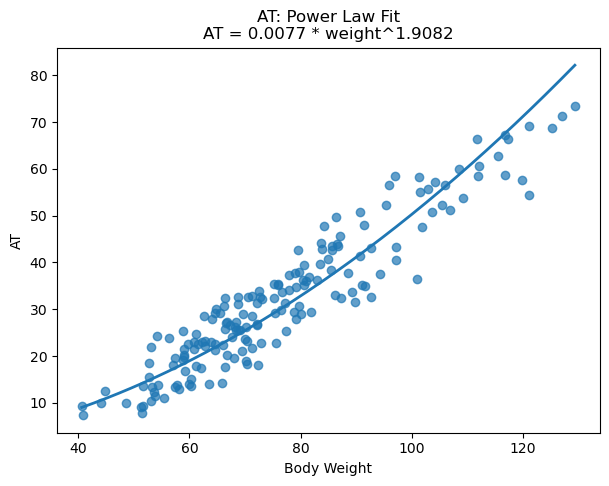

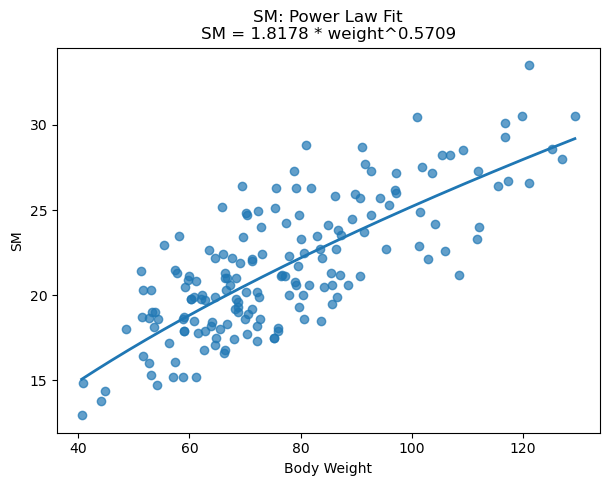

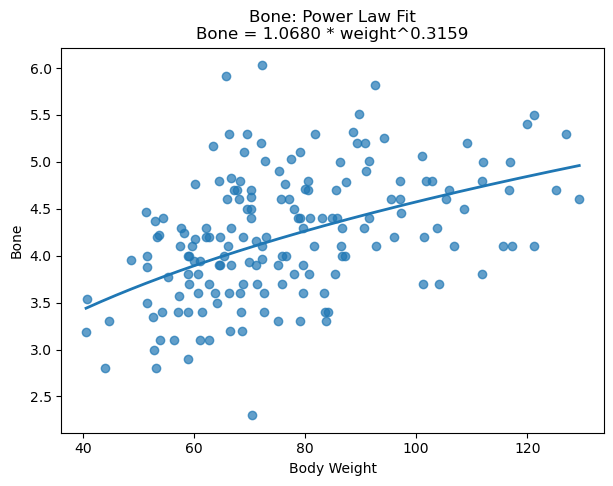

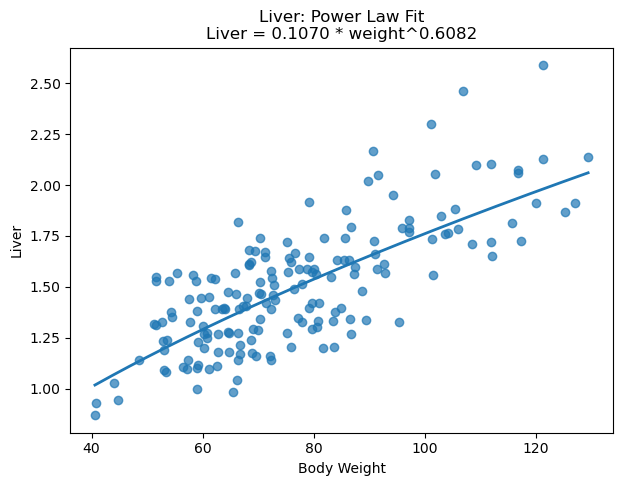

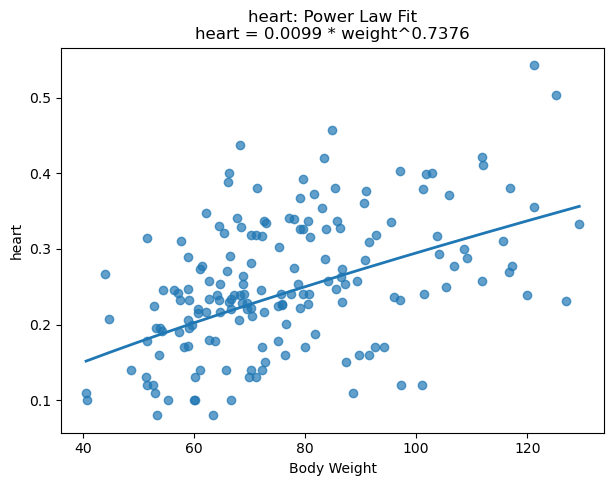

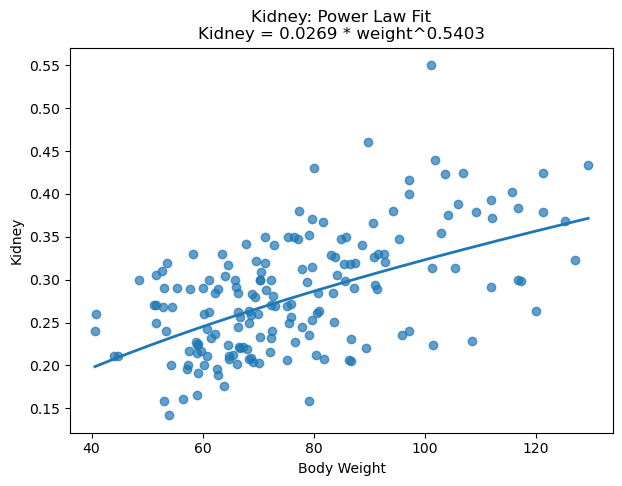

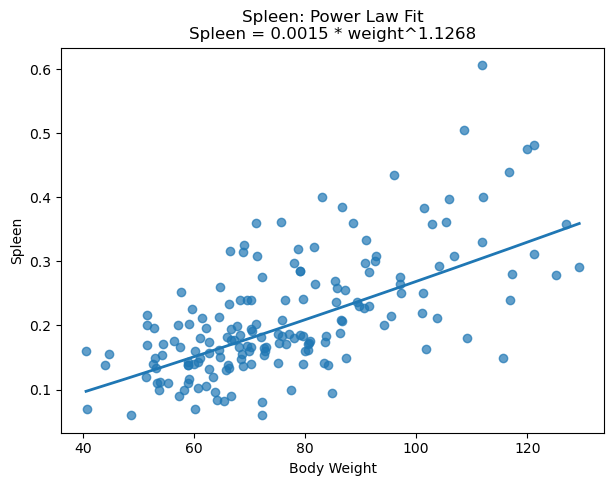

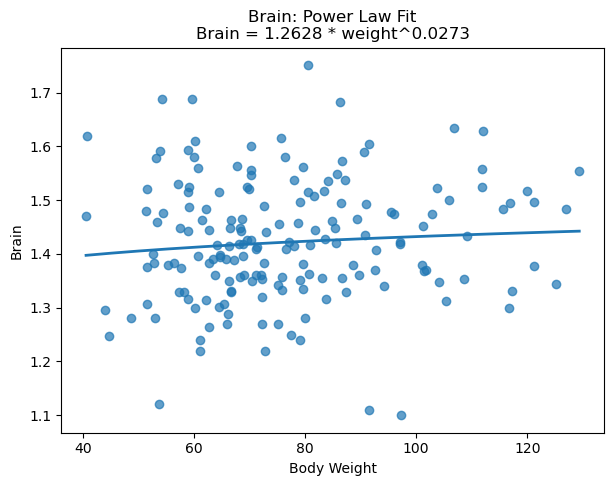

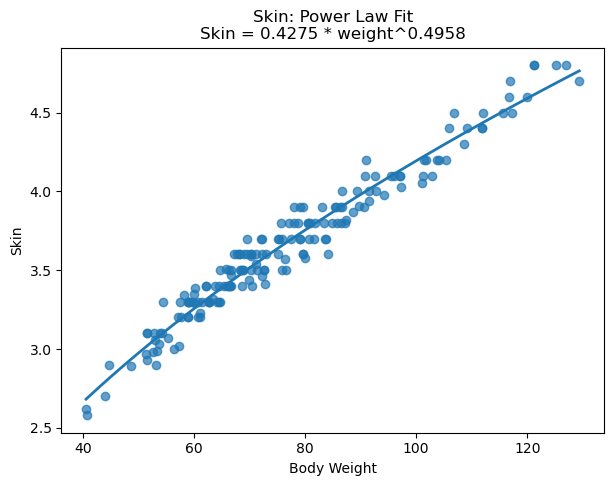

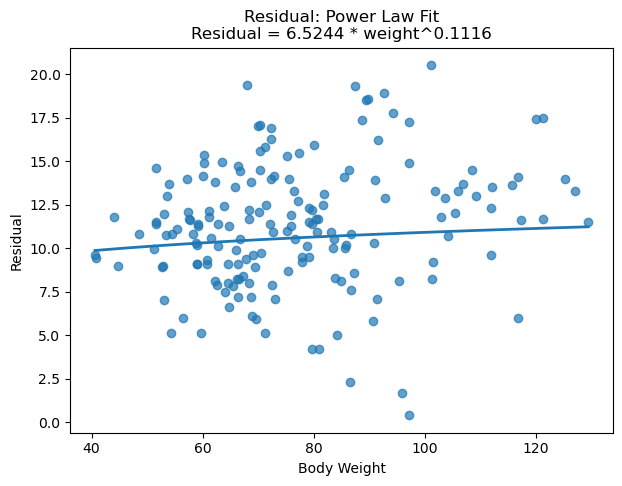

In [41]:
def plot_organ_power_law(organ):
    temp = cleaned_data[organ]
    result = summary_table[summary_table["organ"] == organ].iloc[0]

    alpha = result["alpha"]
    beta = result["beta"]

    x_grid = np.linspace(temp[weight_col].min(), temp[weight_col].max(), 200)
    y_grid = alpha * x_grid ** beta

    plt.figure(figsize=(7, 5))
    plt.scatter(temp[weight_col], temp[organ], alpha=0.7)
    plt.plot(x_grid, y_grid, linewidth=2)

    plt.xlabel("Body Weight")
    plt.ylabel(organ)
    plt.title(f"{organ}: Power Law Fit\n{organ} = {alpha:.4f} * weight^{beta:.4f}")
    plt.show()

for organ in organ_cols:
    plot_organ_power_law(organ)

### 13. Residual Plots for All organs

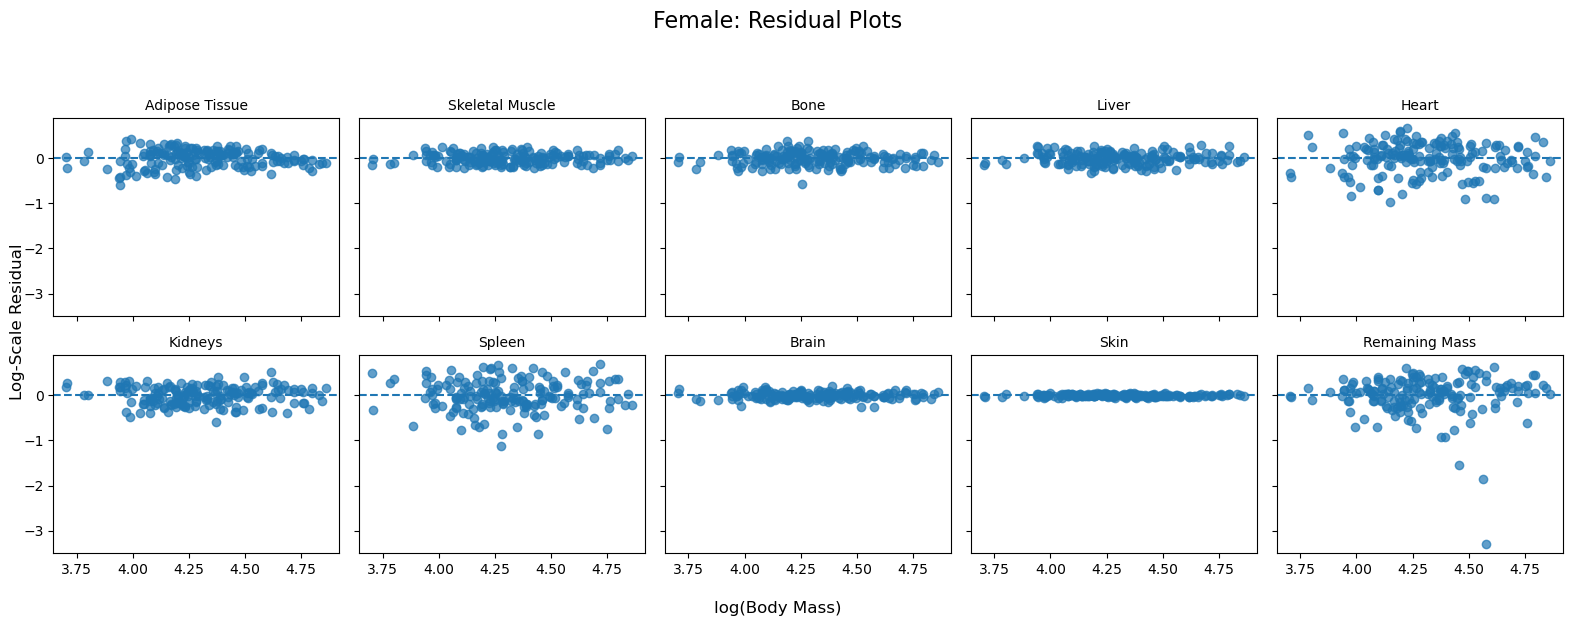

In [42]:
# ======================================================
# Residual plots as a 2x5 figure array
# Saves to current working directory
# ======================================================

import matplotlib.pyplot as plt

nrows = 2
ncols = 5

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(16, 6),
    sharex=True,
    sharey=True
)

fig.suptitle(
    "Female: Residual Plots",
    fontsize=16,
    y=1.02
)

axes = axes.flatten()

for ax, organ in zip(axes, organ_cols):

    temp = cleaned_data[organ]

    ax.scatter(
        temp["log_x"],
        temp["log_residual"],
        alpha=0.7
    )

    ax.axhline(
        0,
        linestyle="--"
    )

    organ_label = organ_name_map.get(organ, organ)

    ax.set_title(
        organ_label,
        fontsize=10
    )

# Remove unused axes if needed
for ax in axes[len(organ_cols):]:
    fig.delaxes(ax)

# Shared axis labels
fig.supxlabel("log(Body Mass)")
fig.supylabel("Log-Scale Residual")

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

# Save in same folder
plt.savefig(
    "Figure_Residuals_All_Organs_Female.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 14. Q-Q Plots for all organs

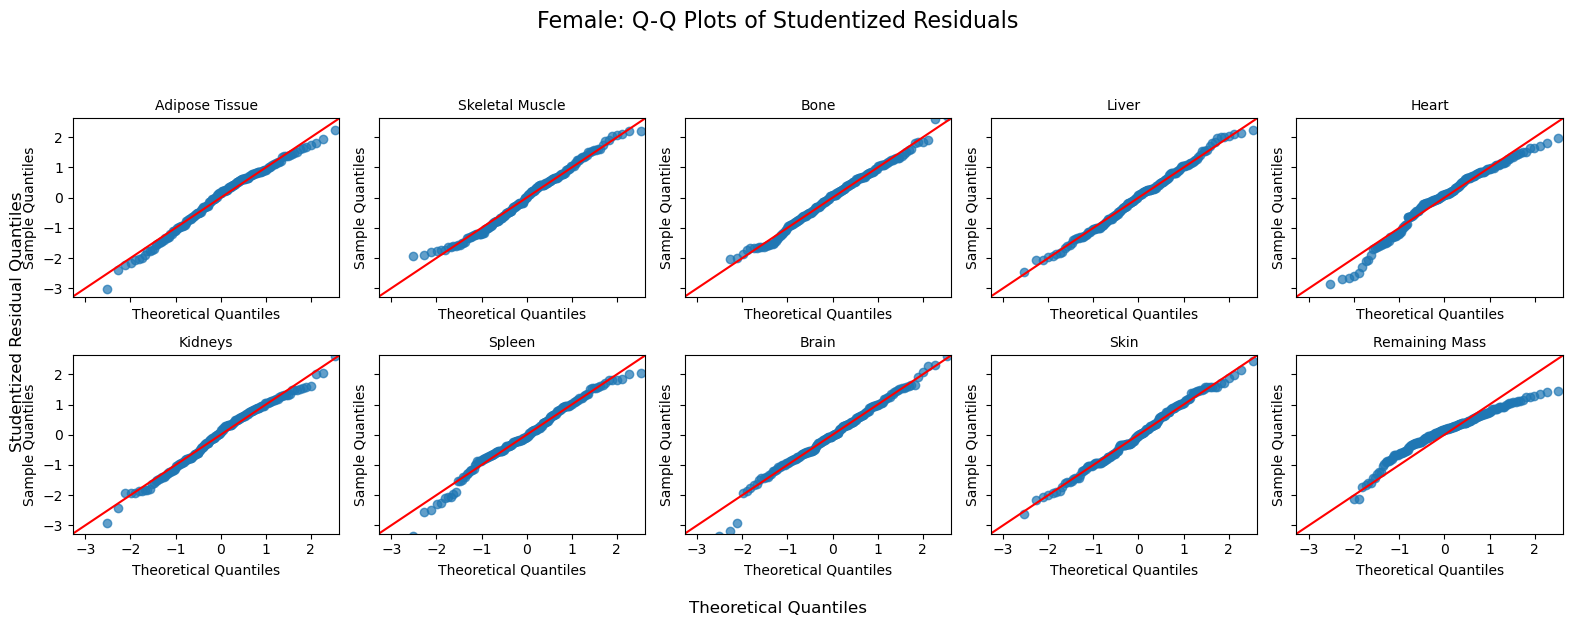

In [43]:
# ======================================================
# Q-Q plots as a 2x5 figure array
# Saves to current working directory
# ======================================================

import matplotlib.pyplot as plt
import statsmodels.api as sm

nrows = 2
ncols = 5

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(16, 6),
    sharex=True,
    sharey=True
)

fig.suptitle(
    "Female: Q-Q Plots of Studentized Residuals",
    fontsize=16,
    y=1.02
)

axes = axes.flatten()

for ax, organ in zip(axes, organ_cols):

    model = models[organ]

    studentized_residuals = (
        model
        .get_influence()
        .resid_studentized_internal
    )

    sm.qqplot(
        studentized_residuals,
        line="45",
        ax=ax,
        marker='o',
        alpha=0.7
    )

    organ_label = organ_name_map.get(
        organ,
        organ
    )

    ax.set_title(
        organ_label,
        fontsize=10
    )

# Remove unused axes if needed
for ax in axes[len(organ_cols):]:
    fig.delaxes(ax)

# Shared axis labels
fig.supxlabel("Theoretical Quantiles")
fig.supylabel("Studentized Residual Quantiles")

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

# Save in same folder
plt.savefig(
    "Figure_QQPlots_All_Organs_Female.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 15. Correlation Plots for actual versus predicted organ masses. Some don't look so good.

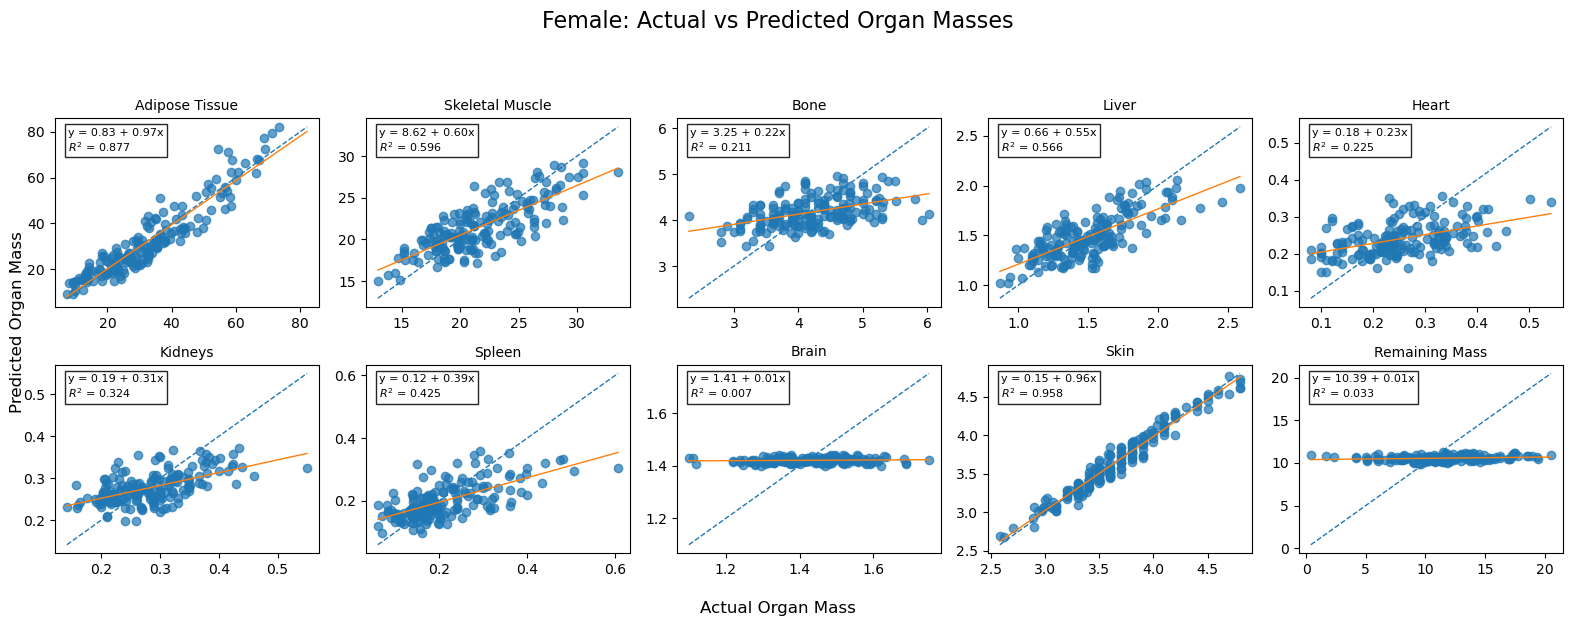

In [44]:
# ======================================================
# Actual vs predicted organ mass plots as a 2x5 figure array
# Saves to current working directory
# Females
# ======================================================

import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

nrows = 2
ncols = 5

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(16, 6),
    sharex=False,
    sharey=False
)

fig.suptitle(
    "Female: Actual vs Predicted Organ Masses",
    fontsize=16,
    y=1.02
)

axes = axes.flatten()

for ax, organ in zip(axes, organ_cols):

    temp = cleaned_data[organ].copy()

    actual = temp[organ]
    predicted = temp["predicted_original"]

    X = sm.add_constant(actual)
    model = sm.OLS(predicted, X).fit()

    intercept = model.params["const"]
    slope = model.params[organ]
    r2 = model.rsquared

    xmin = min(actual.min(), predicted.min())
    xmax = max(actual.max(), predicted.max())

    xline = np.linspace(xmin, xmax, 200)
    yline = intercept + slope * xline

    ax.scatter(
        actual,
        predicted,
        alpha=0.7
    )

    ax.plot(
        [xmin, xmax],
        [xmin, xmax],
        linestyle="--",
        linewidth=1
    )

    ax.plot(
        xline,
        yline,
        linewidth=1
    )

    eq_text = (
        f"y = {intercept:.2f} + {slope:.2f}x\n"
        f"$R^2$ = {r2:.3f}"
    )

    ax.text(
        0.05,
        0.95,
        eq_text,
        transform=ax.transAxes,
        verticalalignment="top",
        fontsize=8,
        bbox=dict(
            boxstyle="square",
            facecolor="white",
            alpha=0.85
        )
    )

    organ_label = organ_name_map.get(organ, organ)

    ax.set_title(
        organ_label,
        fontsize=10
    )

# Remove unused axes if needed
for ax in axes[len(organ_cols):]:
    fig.delaxes(ax)

fig.supxlabel("Actual Organ Mass")
fig.supylabel("Predicted Organ Mass")

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.savefig(
    "Figure_Actual_vs_Predicted_All_Organs_Female.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 16. Bland Altman Plots for each organ

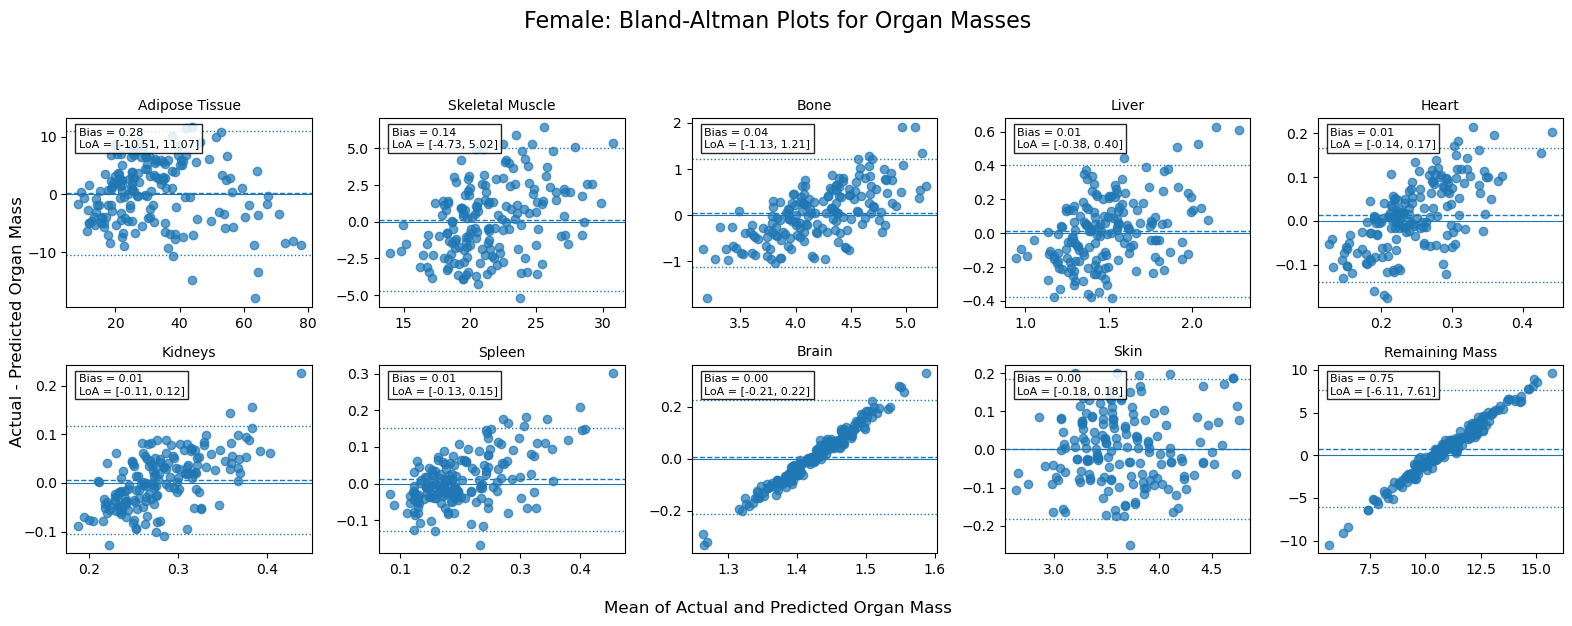

,organ,bias,sd_difference,loa_lower,loa_upper,proportional_bias_slope,proportional_bias_p
0,Adipose Tissue,0.279599,5.503513,-10.507287,11.066485,-0.031531,2.560607e-01
1,Skeletal Muscle,0.141221,2.487716,-4.734703,5.017144,0.291251,2.055330e-07
2,Bone,0.042436,0.598023,-1.129689,1.214561,0.922477,5.746666e-24
3,Liver,0.012995,0.199383,-0.377797,0.403786,0.344972,5.073570e-09
4,Heart,0.012730,0.078299,-0.140736,0.166196,0.883292,1.102685e-22
5,Kidneys,0.005673,0.056664,-0.105389,0.116735,0.751122,1.964035e-20
6,Spleen,0.011340,0.071561,-0.128919,0.151599,0.599861,9.504508e-17
7,Brain,0.004394,0.111858,-0.214848,0.223636,1.945571,4.247159e-135
8,Skin,0.001159,0.093009,-0.181139,0.183456,0.021600,1.745130e-01
9,Remaining Mass,0.746669,3.500095,-6.113517,7.606856,1.917664,7.905894e-139


In [45]:
# ======================================================
# Bland-Altman organ mass plots as a 2x5 figure array
# Saves to current working directory
# Females
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

nrows = 2
ncols = 5

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(16, 6),
    sharex=False,
    sharey=False
)

fig.suptitle(
    "Female: Bland-Altman Plots for Organ Masses",
    fontsize=16,
    y=1.02
)

axes = axes.flatten()

ba_summary_rows = []

for ax, organ in zip(axes, organ_cols):

    temp = cleaned_data[organ].copy()

    temp["difference"] = temp[organ] - temp["predicted_original"]
    temp["mean_measurement"] = (
        temp[organ] + temp["predicted_original"]
    ) / 2

    bias = temp["difference"].mean()
    sd_diff = temp["difference"].std(ddof=1)

    loa_upper = bias + 1.96 * sd_diff
    loa_lower = bias - 1.96 * sd_diff

    X_ba = sm.add_constant(temp["mean_measurement"])
    ba_model = sm.OLS(temp["difference"], X_ba).fit()

    slope = ba_model.params["mean_measurement"]
    p_slope = ba_model.pvalues["mean_measurement"]

    organ_label = organ_name_map.get(organ, organ)

    ba_summary_rows.append({
        "organ": organ_label,
        "bias": bias,
        "sd_difference": sd_diff,
        "loa_lower": loa_lower,
        "loa_upper": loa_upper,
        "proportional_bias_slope": slope,
        "proportional_bias_p": p_slope
    })

    ax.scatter(
        temp["mean_measurement"],
        temp["difference"],
        alpha=0.7
    )

    ax.axhline(
        bias,
        linestyle="--",
        linewidth=1
    )

    ax.axhline(
        loa_upper,
        linestyle=":",
        linewidth=1
    )

    ax.axhline(
        loa_lower,
        linestyle=":",
        linewidth=1
    )

    ax.axhline(
        0,
        linewidth=0.8
    )

    ax.set_title(
        organ_label,
        fontsize=10
    )

    ax.text(
        0.05,
        0.95,
        f"Bias = {bias:.2f}\nLoA = [{loa_lower:.2f}, {loa_upper:.2f}]",
        transform=ax.transAxes,
        verticalalignment="top",
        fontsize=8,
        bbox=dict(
            boxstyle="square",
            facecolor="white",
            alpha=0.85
        )
    )

# Remove unused axes if needed
for ax in axes[len(organ_cols):]:
    fig.delaxes(ax)

fig.supxlabel("Mean of Actual and Predicted Organ Mass")
fig.supylabel("Actual - Predicted Organ Mass")

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.savefig(
    "Figure_BlandAltman_All_Organs_Female.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

ba_summary = pd.DataFrame(ba_summary_rows)
display(ba_summary)

### 17. Forest Plot of $\beta_i$ (scaling exponents) for each organ

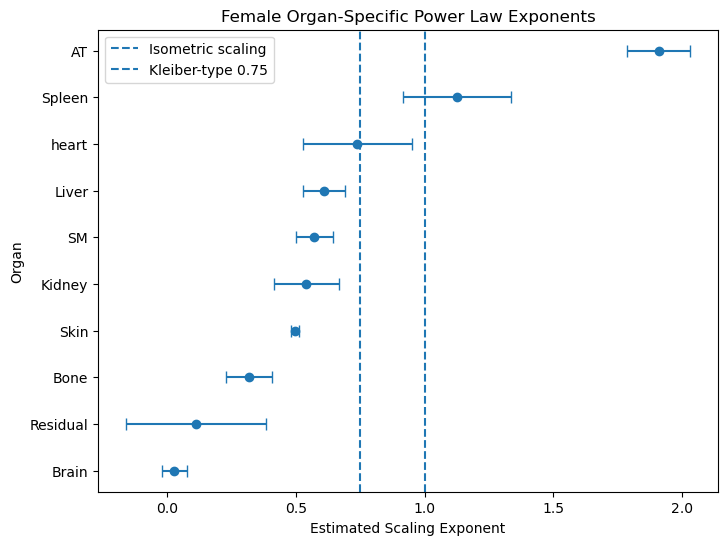

In [46]:
plot_df = summary_table.sort_values("beta")

plt.figure(figsize=(8, 6))

plt.errorbar(
    x=plot_df["beta"],
    y=plot_df["organ"],
    xerr=[
        plot_df["beta"] - plot_df["beta_ci_lower"],
        plot_df["beta_ci_upper"] - plot_df["beta"]
    ],
    fmt="o",
    capsize=4
)

plt.axvline(1.0, linestyle="--", label="Isometric scaling")
plt.axvline(0.75, linestyle="--", label="Kleiber-type 0.75")

plt.xlabel("Estimated Scaling Exponent")
plt.ylabel("Organ")
plt.title("Female Organ-Specific Power Law Exponents")
plt.legend()
plt.show()

### 18. Next we compute the mass fractions.


,organ,mean_mass_fraction,sd_mass_fraction,min_mass_fraction,max_mass_fraction
0,Adipose Tissue,0.400287,0.105522,0.153362,0.596570
1,Skeletal Muscle,0.289485,0.045598,0.195397,0.417739
2,Remaining Mass,0.154273,0.053721,0.004086,0.285059
3,Bone,0.057306,0.012417,0.032659,0.089901
4,Skin,0.049035,0.006077,0.036307,0.064638
5,Liver,0.020037,0.003298,0.013920,0.030071
6,Brain,0.019676,0.004941,0.010746,0.039755
7,Kidneys,0.003801,0.000881,0.001997,0.006380
8,Heart,0.003366,0.001078,0.001188,0.006403
9,Spleen,0.002734,0.000896,0.000831,0.005419


Sum of mean mass fractions:
1.0


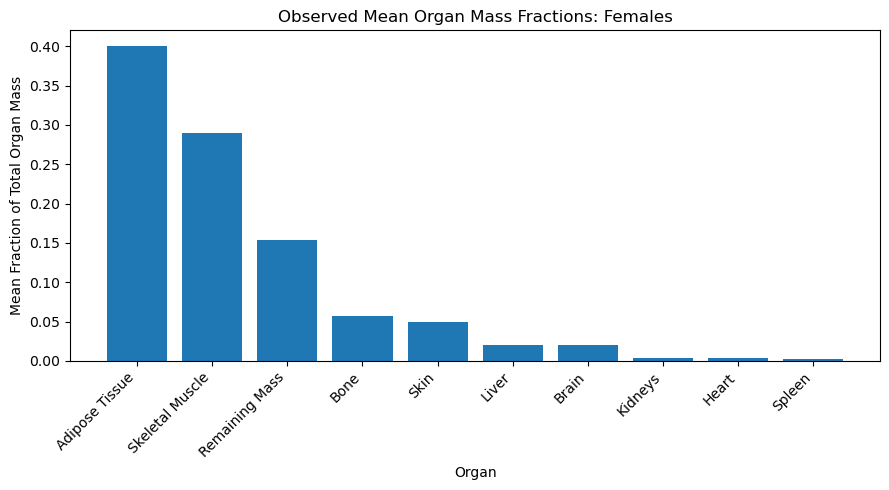

,weight,total_organ_mass,AT_mass_fraction,SM_mass_fraction,Bone_mass_fraction,Liver_mass_fraction,heart_mass_fraction,Kidney_mass_fraction,Spleen_mass_fraction,Brain_mass_fraction,Skin_mass_fraction,Residual_mass_fraction
0,101.41,101.373,0.543537,0.245628,0.041431,0.015349,0.002367,0.002210,0.003788,0.013505,0.041431,0.090754
1,83.49,83.495,0.475478,0.271873,0.043116,0.015953,0.005030,0.003413,0.001689,0.018169,0.045512,0.119768
2,86.42,86.326,0.576883,0.262957,0.047494,0.015557,0.003047,0.003684,0.002409,0.017306,0.044019,0.026643
3,51.60,51.600,0.181202,0.393217,0.075194,0.029651,0.002326,0.005233,0.003876,0.029457,0.056783,0.223062
4,59.16,59.176,0.282209,0.346424,0.067595,0.020785,0.003295,0.003802,0.003414,0.025754,0.055766,0.190956


In [47]:
# ======================================================
# Observed organ mass fractions
# f_i = M_i / sum_j M_j
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------
# Build dataframe from observed organ masses
# ------------------------------------------------------

mass_fraction_df = organ_df[[weight_col] + organ_cols].copy()

for col in [weight_col] + organ_cols:
    mass_fraction_df[col] = pd.to_numeric(
        mass_fraction_df[col],
        errors="coerce"
    )

mass_fraction_df = mass_fraction_df.replace(
    [np.inf, -np.inf],
    np.nan
)

mass_fraction_df = mass_fraction_df.dropna()

# Keep only positive body weight and positive organ masses

mass_fraction_df = mass_fraction_df[
    mass_fraction_df[weight_col] > 0
].copy()

for organ in organ_cols:
    mass_fraction_df = mass_fraction_df[
        mass_fraction_df[organ] > 0
    ].copy()

# ------------------------------------------------------
# Compute total observed organ mass and mass fractions
# ------------------------------------------------------

mass_fraction_df["total_organ_mass"] = (
    mass_fraction_df[organ_cols].sum(axis=1)
)

for organ in organ_cols:
    mass_fraction_df[f"{organ}_mass_fraction"] = (
        mass_fraction_df[organ] /
        mass_fraction_df["total_organ_mass"]
    )

# ------------------------------------------------------
# Summarize mean mass fractions
# ------------------------------------------------------

mean_mass_fractions = []

for organ in organ_cols:
    mean_mass_fractions.append({
        "organ": organ_name_map.get(organ, organ),
        "mean_mass_fraction": mass_fraction_df[f"{organ}_mass_fraction"].mean(),
        "sd_mass_fraction": mass_fraction_df[f"{organ}_mass_fraction"].std(ddof=1),
        "min_mass_fraction": mass_fraction_df[f"{organ}_mass_fraction"].min(),
        "max_mass_fraction": mass_fraction_df[f"{organ}_mass_fraction"].max()
    })

mean_mass_fractions = pd.DataFrame(mean_mass_fractions)

mean_mass_fractions = mean_mass_fractions.sort_values(
    "mean_mass_fraction",
    ascending=False
).reset_index(drop=True)

display(mean_mass_fractions)

print("Sum of mean mass fractions:")
print(mean_mass_fractions["mean_mass_fraction"].sum())

# ------------------------------------------------------
# Plot mean observed organ mass fractions
# ------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.bar(
    mean_mass_fractions["organ"],
    mean_mass_fractions["mean_mass_fraction"]
)

plt.ylabel("Mean Fraction of Total Organ Mass")
plt.xlabel("Organ")
plt.title("Observed Mean Organ Mass Fractions: Females")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ------------------------------------------------------
# Preview participant-level mass fractions
# ------------------------------------------------------

display(
    mass_fraction_df[
        [weight_col, "total_organ_mass"]
        + [f"{organ}_mass_fraction" for organ in organ_cols]
    ].head()
)

### 20. Visualization of mass fraction

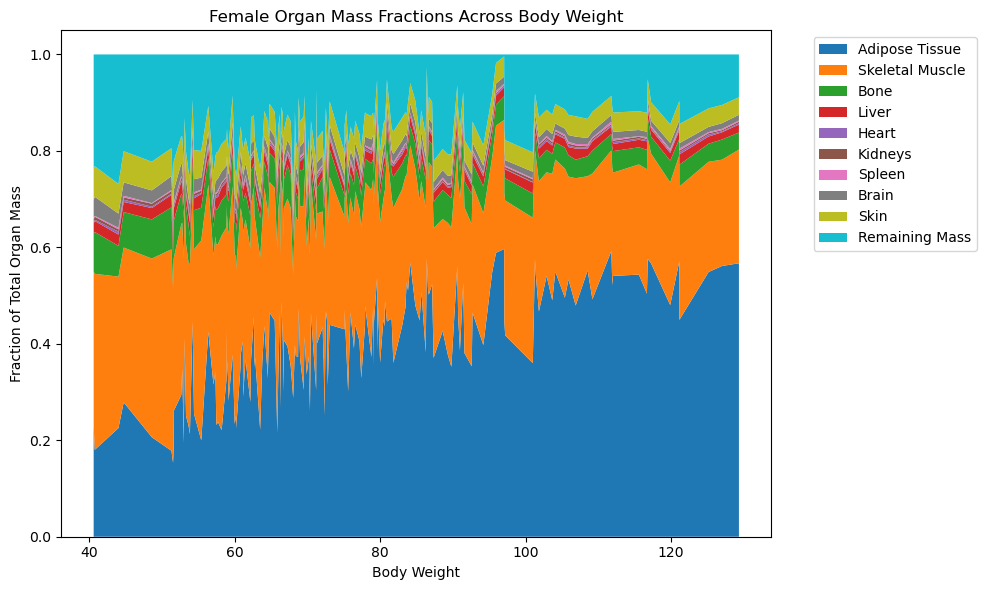

In [48]:
# ======================================================
# Stackplot of observed organ mass fractions across body weight
# ======================================================

mass_fraction_columns = [
    f"{organ}_mass_fraction"
    for organ in organ_cols
]

mass_fraction_df_sorted = mass_fraction_df.sort_values(weight_col)

plt.figure(figsize=(10, 6))

plt.stackplot(
    mass_fraction_df_sorted[weight_col],
    [
        mass_fraction_df_sorted[col]
        for col in mass_fraction_columns
    ],
    labels=[
        organ_name_map[organ]
        for organ in organ_cols
    ]
)

plt.xlabel("Body Weight")
plt.ylabel("Fraction of Total Organ Mass")
plt.title("Female Organ Mass Fractions Across Body Weight")

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.05, 1)
)

plt.tight_layout()
plt.show()

### 21. Di's $w_i(M)$ which represent the weights for each organ $\beta_i$. The weights represent the fraction of total REE contributed by organ or tissue compartment.

In [49]:
# ======================================================
# Model-derived metabolic contribution weights
# All organs modeled as power laws
#
# w_i(M) = K_i alpha_i M^beta_i / sum_j K_j alpha_j M^beta_j
# ======================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------
# Elia coefficients
# ------------------------------------------------------

elia_k = {
    "AT": 4.5,
    "SM": 13,
    "Bone": 12,
    "Liver": 200,
    "heart": 440,
    "Kidney": 440,
    "Spleen": 12,
    "Brain": 240,
    "Skin": 12,
    "Residual": 12
}

# ------------------------------------------------------
# Build model-derived weight dataframe
# ------------------------------------------------------

model_weight_df = organ_df[[weight_col] + organ_cols].copy()

for col in [weight_col] + organ_cols:
    model_weight_df[col] = pd.to_numeric(
        model_weight_df[col],
        errors="coerce"
    )

model_weight_df = model_weight_df.replace([np.inf, -np.inf], np.nan)
model_weight_df = model_weight_df.dropna()
model_weight_df = model_weight_df[model_weight_df[weight_col] > 0].copy()

# ------------------------------------------------------
# Compute model-predicted organ MR terms
# K_i alpha_i M^beta_i
# ------------------------------------------------------

model_weight_df["total_model_mr"] = 0.0

for organ in organ_cols:

    row = summary_table[
        summary_table["organ"] == organ
    ]

    if row.empty:
        raise ValueError(f"{organ} not found in summary_table.")

    alpha_i = row["alpha"].iloc[0]
    beta_i = row["beta"].iloc[0]
    K_i = elia_k[organ]

    model_weight_df[f"{organ}_model_mr"] = (
        K_i
        * alpha_i
        * model_weight_df[weight_col] ** beta_i
    )

    model_weight_df["total_model_mr"] += model_weight_df[f"{organ}_model_mr"]

# ------------------------------------------------------
# Compute w_i(M)
# ------------------------------------------------------

for organ in organ_cols:
    model_weight_df[f"{organ}_w"] = (
        model_weight_df[f"{organ}_model_mr"]
        / model_weight_df["total_model_mr"]
    )

# ------------------------------------------------------
# Mean model-derived weights
# ------------------------------------------------------

mean_model_weights = pd.DataFrame({
    "organ": [
        organ_name_map.get(organ, organ)
        for organ in organ_cols
    ],
    "mean_weight": [
        model_weight_df[f"{organ}_w"].mean()
        for organ in organ_cols
    ]
})

mean_model_weights = mean_model_weights.sort_values(
    "mean_weight",
    ascending=False
).reset_index(drop=True)

display(mean_model_weights)

print("Sum of mean model-derived weights:")
print(mean_model_weights["mean_weight"].sum())

,organ,mean_weight
0,Brain,0.229033
1,Liver,0.196331
2,Skeletal Muscle,0.184558
3,Adipose Tissue,0.090786
4,Remaining Mass,0.084887
5,Kidneys,0.080860
6,Heart,0.069621
7,Bone,0.033382
8,Skin,0.028984
9,Spleen,0.001557


Sum of mean model-derived weights:
1.0


### 24. Visualization of organ weights (fraction of contribution to REE)

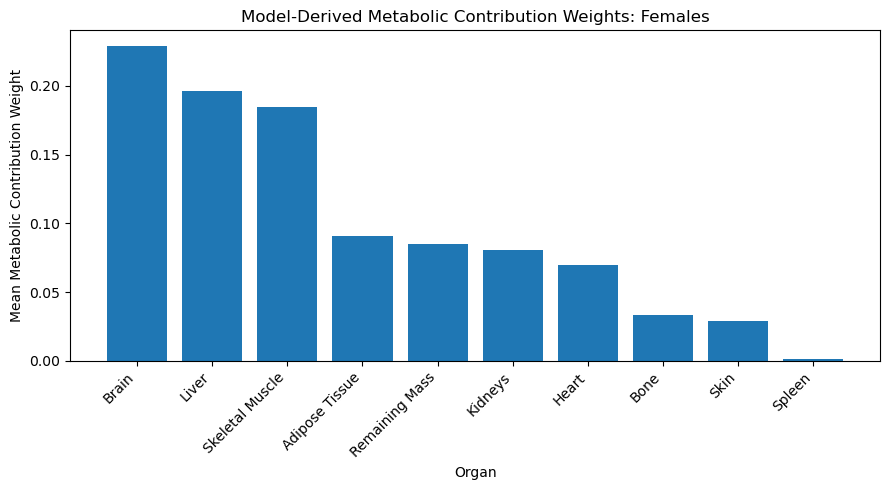

In [50]:
plt.figure(figsize=(9, 5))

plt.bar(
    mean_model_weights["organ"],
    mean_model_weights["mean_weight"]
)

plt.ylabel("Mean Metabolic Contribution Weight")
plt.xlabel("Organ")
plt.title("Model-Derived Metabolic Contribution Weights: Females")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 25. I feel I did this but I need big $\beta$

In [51]:
# ======================================================
# Chunk
# Direct whole-body REE power law
#
# REE = alpha * M^beta
#
# This is the observed (direct) whole-body scaling exponent
# used later for comparison with the effective beta derived
# from the organ model.
# ======================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm

# ------------------------------------------------------
# Column names
# ------------------------------------------------------

weight_col = "weight"
ree_col = "Measured RMR"

# ------------------------------------------------------
# Keep only positive, non-missing observations
# ------------------------------------------------------

ree_df = df[[weight_col, ree_col]].copy()

ree_df[weight_col] = pd.to_numeric(
    ree_df[weight_col],
    errors="coerce"
)

ree_df[ree_col] = pd.to_numeric(
    ree_df[ree_col],
    errors="coerce"
)

ree_df = ree_df.replace(
    [np.inf, -np.inf],
    np.nan
)

ree_df = ree_df.dropna()

ree_df = ree_df[
    (ree_df[weight_col] > 0)
    & (ree_df[ree_col] > 0)
].copy()

# ------------------------------------------------------
# Natural log transform
# ------------------------------------------------------

ree_df["ln_M"] = np.log(
    ree_df[weight_col]
)

ree_df["ln_REE"] = np.log(
    ree_df[ree_col]
)

# ------------------------------------------------------
# Fit log-log power law
# ------------------------------------------------------

X = sm.add_constant(
    ree_df["ln_M"]
)

y = ree_df["ln_REE"]

ree_power_model = sm.OLS(
    y,
    X
).fit()

print(ree_power_model.summary())

# ------------------------------------------------------
# Extract parameters
# ------------------------------------------------------

ln_alpha_REE_direct = (
    ree_power_model.params["const"]
)

beta_REE_direct = (
    ree_power_model.params["ln_M"]
)

alpha_REE_direct = np.exp(
    ln_alpha_REE_direct
)

# ------------------------------------------------------
# Confidence intervals
# ------------------------------------------------------

ci = ree_power_model.conf_int()

ln_alpha_ci_lower = ci.loc["const", 0]
ln_alpha_ci_upper = ci.loc["const", 1]

beta_REE_direct_ci_lower = ci.loc["ln_M", 0]
beta_REE_direct_ci_upper = ci.loc["ln_M", 1]

alpha_REE_direct_ci_lower = np.exp(
    ln_alpha_ci_lower
)

alpha_REE_direct_ci_upper = np.exp(
    ln_alpha_ci_upper
)

# ------------------------------------------------------
# Print results
# ------------------------------------------------------

print("\nPower-law model:")
print("REE = alpha * M^beta")

print("\nParameter estimates:")

print(
    f"alpha = {alpha_REE_direct:.6f}"
)

print(
    f"95% CI for alpha = "
    f"({alpha_REE_direct_ci_lower:.6f}, "
    f"{alpha_REE_direct_ci_upper:.6f})"
)

print(
    f"\nbeta = {beta_REE_direct:.6f}"
)

print(
    f"95% CI for beta = "
    f"({beta_REE_direct_ci_lower:.6f}, "
    f"{beta_REE_direct_ci_upper:.6f})"
)

print(
    f"\nR-squared = "
    f"{ree_power_model.rsquared:.6f}"
)

print(
    f"Adjusted R-squared = "
    f"{ree_power_model.rsquared_adj:.6f}"
)

print(
    f"Number of observations = "
    f"{len(ree_df)}"
)

# ------------------------------------------------------
# Predicted REE on original scale
# ------------------------------------------------------

ree_df["REE_predicted"] = (
    alpha_REE_direct
    * ree_df[weight_col] ** beta_REE_direct
)

# ------------------------------------------------------
# Save direct REE scaling results
# ------------------------------------------------------

ree_power_results = {
    "alpha_REE_direct": alpha_REE_direct,
    "alpha_REE_direct_ci_lower": alpha_REE_direct_ci_lower,
    "alpha_REE_direct_ci_upper": alpha_REE_direct_ci_upper,
    "beta_REE_direct": beta_REE_direct,
    "beta_REE_direct_ci_lower": beta_REE_direct_ci_lower,
    "beta_REE_direct_ci_upper": beta_REE_direct_ci_upper,
    "r_squared": ree_power_model.rsquared,
    "adj_r_squared": ree_power_model.rsquared_adj,
    "n": len(ree_df)
}

display(
    pd.DataFrame(
        [ree_power_results]
    )
)

display(
    ree_df.head()
)

                            OLS Regression Results                            
Dep. Variable:                 ln_REE   R-squared:                       0.695
Model:                            OLS   Adj. R-squared:                  0.693
Method:                 Least Squares   F-statistic:                     389.5
Date:                Sun, 21 Jun 2026   Prob (F-statistic):           6.04e-46
Time:                        08:02:33   Log-Likelihood:                 177.19
No. Observations:                 173   AIC:                            -350.4
Df Residuals:                     171   BIC:                            -344.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.9479      0.118     41.762      0.0

,alpha_REE_direct,alpha_REE_direct_ci_lower,alpha_REE_direct_ci_upper,beta_REE_direct,beta_REE_direct_ci_lower,beta_REE_direct_ci_upper,r_squared,adj_r_squared,n
0,140.883116,111.504014,178.003029,0.541631,0.487457,0.595804,0.694911,0.693126,173


,weight,Measured RMR,ln_M,ln_REE,REE_predicted
0,101.41,1769.0,4.619172,7.478170,1719.546333
1,83.49,1643.0,4.424727,7.404279,1547.658589
2,86.42,1532.0,4.459219,7.334329,1576.843827
3,51.60,1145.0,3.943522,7.043160,1192.566488
4,59.16,1535.0,4.080246,7.336286,1284.232924


### 26. Bland Atlmans for REE predicted by organs versus REE measured

Female Bland-Altman: measured REE - organ-model predicted REE
n = 173
Mean measured REE = 1472.72
Mean predicted REE = 1513.24
Bias = -40.52
Lower LOA = -281.38
Upper LOA = 200.34


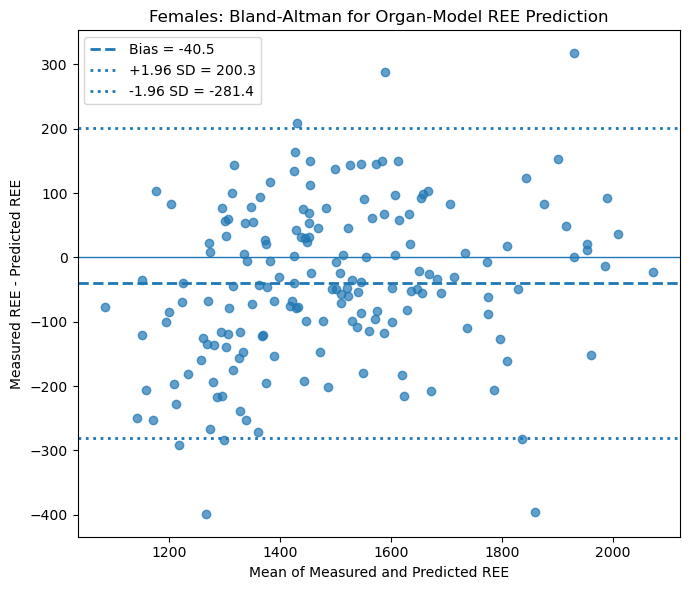

,weight,Measured RMR,REE_pred_powerlaw_organs,Adipose Tissue REE_hat,Skeletal Muscle REE_hat,Bone REE_hat,Liver REE_hat,Heart REE_hat,Kidneys REE_hat,Spleen REE_hat,Brain REE_hat,Skin REE_hat,Remaining Mass REE_hat
count,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000
mean,76.697052,1472.722543,1513.242506,143.642325,279.512686,50.149496,297.695885,106.006142,122.341757,2.401329,340.988440,43.791647,126.712800
std,19.096361,233.291547,204.474180,70.353753,39.247806,3.871139,44.571036,19.318508,16.243514,0.676365,2.264667,5.329809,3.441390
min,40.600000,1018.000000,1122.441689,40.515966,195.814289,41.285491,203.631487,66.690337,87.403091,1.167687,335.373633,32.184250,118.375458
25%,62.720000,1308.000000,1364.518050,92.907006,251.005158,47.364825,265.286764,91.914942,110.554575,1.906123,339.385178,39.929782,124.263697
50%,72.350000,1477.000000,1466.886601,122.016712,272.332317,49.550625,289.362143,102.127576,119.424170,2.238965,340.713100,42.860269,126.260723
75%,86.700000,1622.000000,1619.055300,172.332559,301.969860,52.464932,323.021806,116.709512,131.688698,2.745299,342.402727,46.883278,128.836629
max,129.350000,2089.000000,2083.347705,369.754365,379.456574,59.531645,412.001967,156.771521,163.464105,4.308867,346.168420,57.169999,134.720242


In [52]:
# ======================================================
# Bland-Altman: measured REE vs organ-model predicted REE
#
# Predicted REE = sum_i K_i alpha_i M^beta_i
# Uses alpha_i and beta_i from summary_table
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------
# Build participant-level dataframe
# ------------------------------------------------------

ree_ba_df = organ_df[[weight_col, ree_col] + organ_cols].copy()

for col in [weight_col, ree_col] + organ_cols:
    ree_ba_df[col] = pd.to_numeric(
        ree_ba_df[col],
        errors="coerce"
    )

ree_ba_df = ree_ba_df.replace(
    [np.inf, -np.inf],
    np.nan
)

ree_ba_df = ree_ba_df.dropna()

ree_ba_df = ree_ba_df[
    (ree_ba_df[weight_col] > 0)
    & (ree_ba_df[ree_col] > 0)
].copy()

for organ in organ_cols:
    ree_ba_df = ree_ba_df[
        ree_ba_df[organ] > 0
    ].copy()

# ------------------------------------------------------
# Predicted REE from organ power-law model
# REE_hat = sum_i K_i alpha_i M^beta_i
# ------------------------------------------------------

ree_ba_df["REE_pred_powerlaw_organs"] = 0.0

for organ in organ_cols:

    row = summary_table[
        summary_table["organ"] == organ
    ]

    if row.empty:
        raise ValueError(
            f"{organ} not found in summary_table. "
            "Make sure summary_table uses raw organ column names."
        )

    alpha_i = row["alpha"].iloc[0]
    beta_i = row["beta"].iloc[0]
    K_i = elia_k[organ]

    ree_ba_df[f"{organ}_mass_hat"] = (
        alpha_i
        * ree_ba_df[weight_col] ** beta_i
    )

    ree_ba_df[f"{organ_name_map[organ]} REE_hat"] = (
        K_i
        * ree_ba_df[f"{organ}_mass_hat"]
    )

    ree_ba_df["REE_pred_powerlaw_organs"] += (
        ree_ba_df[f"{organ_name_map[organ]} REE_hat"]
    )

# ------------------------------------------------------
# Bland-Altman calculations
# ------------------------------------------------------

ree_ba_df["ba_mean"] = (
    ree_ba_df[ree_col]
    + ree_ba_df["REE_pred_powerlaw_organs"]
) / 2

ree_ba_df["ba_diff"] = (
    ree_ba_df[ree_col]
    - ree_ba_df["REE_pred_powerlaw_organs"]
)

bias = ree_ba_df["ba_diff"].mean()
sd_diff = ree_ba_df["ba_diff"].std(ddof=1)

loa_upper = bias + 1.96 * sd_diff
loa_lower = bias - 1.96 * sd_diff

# ------------------------------------------------------
# Print results
# ------------------------------------------------------

print("Female Bland-Altman: measured REE - organ-model predicted REE")
print(f"n = {len(ree_ba_df)}")
print(f"Mean measured REE = {ree_ba_df[ree_col].mean():.2f}")
print(f"Mean predicted REE = {ree_ba_df['REE_pred_powerlaw_organs'].mean():.2f}")
print(f"Bias = {bias:.2f}")
print(f"Lower LOA = {loa_lower:.2f}")
print(f"Upper LOA = {loa_upper:.2f}")

# ------------------------------------------------------
# Plot
# ------------------------------------------------------

plt.figure(figsize=(7, 6))

plt.scatter(
    ree_ba_df["ba_mean"],
    ree_ba_df["ba_diff"],
    alpha=0.7
)

plt.axhline(
    bias,
    linestyle="--",
    linewidth=2,
    label=f"Bias = {bias:.1f}"
)

plt.axhline(
    loa_upper,
    linestyle=":",
    linewidth=2,
    label=f"+1.96 SD = {loa_upper:.1f}"
)

plt.axhline(
    loa_lower,
    linestyle=":",
    linewidth=2,
    label=f"-1.96 SD = {loa_lower:.1f}"
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel("Mean of Measured and Predicted REE")
plt.ylabel("Measured REE - Predicted REE")
plt.title("Females: Bland-Altman for Organ-Model REE Prediction")

plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------
# Optional: display organ REE components with mapped names
# ------------------------------------------------------

component_cols = [
    f"{organ_name_map[organ]} REE_hat"
    for organ in organ_cols
]

display(
    ree_ba_df[
        [weight_col, ree_col, "REE_pred_powerlaw_organs"]
        + component_cols
    ].describe()
)

### 27. Correlation between Actual versus Predicted REE

Female organ power-law parameters used in REE reconstruction


,Organ,alpha,beta,K,organ_mass_R2
0,Adipose Tissue,0.007674,1.908208,4.5,0.848963
1,Skeletal Muscle,1.817761,0.570935,13.0,0.589667
2,Bone,1.067965,0.315854,12.0,0.219329
3,Liver,0.107044,0.608167,200.0,0.555704
4,Heart,0.009865,0.737628,440.0,0.218088
5,Kidneys,0.026854,0.540290,440.0,0.295906
6,Spleen,0.001499,1.126771,12.0,0.396273
7,Brain,1.262818,0.027340,240.0,0.006999
8,Skin,0.427461,0.495836,12.0,0.956624
9,Remaining Mass,6.524367,0.111619,12.0,0.003838



Female actual vs predicted REE
n = 173
Mean measured REE = 1472.72
Mean predicted REE = 1513.24
Mean difference measured - predicted = -40.52
R^2 actual vs predicted = 0.7232


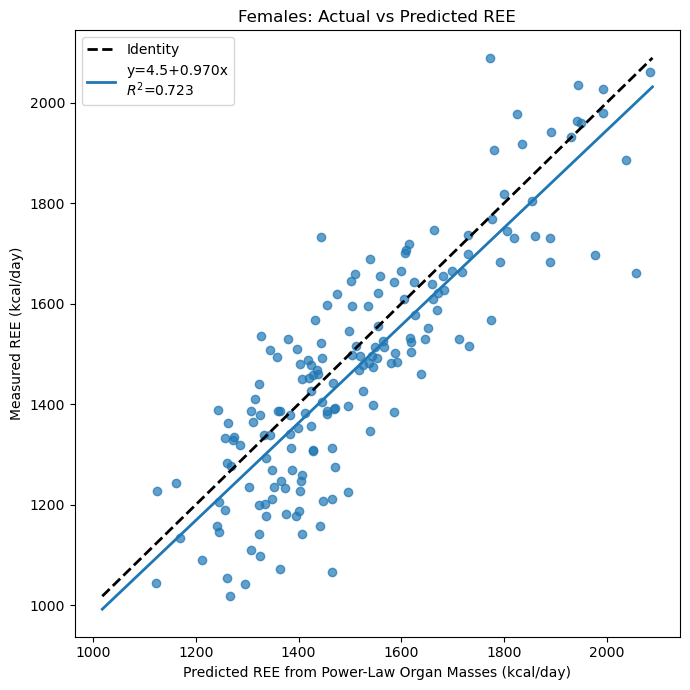

,weight,Measured RMR,REE_pred_powerlaw_organs,Adipose Tissue REE_hat,Skeletal Muscle REE_hat,Bone REE_hat,Liver REE_hat,Heart REE_hat,Kidneys REE_hat,Spleen REE_hat,Brain REE_hat,Skin REE_hat,Remaining Mass REE_hat
count,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000
mean,76.697052,1472.722543,1513.242506,143.642325,279.512686,50.149496,297.695885,106.006142,122.341757,2.401329,340.988440,43.791647,126.712800
std,19.096361,233.291547,204.474180,70.353753,39.247806,3.871139,44.571036,19.318508,16.243514,0.676365,2.264667,5.329809,3.441390
min,40.600000,1018.000000,1122.441689,40.515966,195.814289,41.285491,203.631487,66.690337,87.403091,1.167687,335.373633,32.184250,118.375458
25%,62.720000,1308.000000,1364.518050,92.907006,251.005158,47.364825,265.286764,91.914942,110.554575,1.906123,339.385178,39.929782,124.263697
50%,72.350000,1477.000000,1466.886601,122.016712,272.332317,49.550625,289.362143,102.127576,119.424170,2.238965,340.713100,42.860269,126.260723
75%,86.700000,1622.000000,1619.055300,172.332559,301.969860,52.464932,323.021806,116.709512,131.688698,2.745299,342.402727,46.883278,128.836629
max,129.350000,2089.000000,2083.347705,369.754365,379.456574,59.531645,412.001967,156.771521,163.464105,4.308867,346.168420,57.169999,134.720242


In [53]:
# ======================================================
# Actual vs predicted REE
#
# Predicted REE = sum_i K_i * alpha_i * M^beta_i
#
# Uses organ alpha_i and beta_i from summary_table
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# ------------------------------------------------------
# Build participant-level dataframe
# ------------------------------------------------------

ree_pred_df = organ_df[[weight_col, ree_col] + organ_cols].copy()

for col in [weight_col, ree_col] + organ_cols:
    ree_pred_df[col] = pd.to_numeric(
        ree_pred_df[col],
        errors="coerce"
    )

ree_pred_df = ree_pred_df.replace(
    [np.inf, -np.inf],
    np.nan
)

ree_pred_df = ree_pred_df.dropna()

ree_pred_df = ree_pred_df[
    (ree_pred_df[weight_col] > 0)
    & (ree_pred_df[ree_col] > 0)
].copy()

for organ in organ_cols:
    ree_pred_df = ree_pred_df[
        ree_pred_df[organ] > 0
    ].copy()

# ------------------------------------------------------
# Predict REE from organ power laws
# ------------------------------------------------------

ree_pred_df["REE_pred_powerlaw_organs"] = 0.0

params_rows = []

for organ in organ_cols:

    row = summary_table[
        summary_table["organ"] == organ
    ]

    if row.empty:
        raise ValueError(
            f"{organ} not found in summary_table. "
            "summary_table must contain raw organ column names."
        )

    alpha_i = row["alpha"].iloc[0]
    beta_i = row["beta"].iloc[0]
    r2_i = row["r_squared"].iloc[0]
    K_i = elia_k[organ]

    organ_label = organ_name_map.get(organ, organ)

    ree_pred_df[f"{organ}_mass_hat"] = (
        alpha_i
        * ree_pred_df[weight_col] ** beta_i
    )

    ree_pred_df[f"{organ_label} REE_hat"] = (
        K_i
        * ree_pred_df[f"{organ}_mass_hat"]
    )

    ree_pred_df["REE_pred_powerlaw_organs"] += (
        ree_pred_df[f"{organ_label} REE_hat"]
    )

    params_rows.append({
        "Organ": organ_label,
        "alpha": alpha_i,
        "beta": beta_i,
        "K": K_i,
        "organ_mass_R2": r2_i
    })

params_df = pd.DataFrame(params_rows)

# ------------------------------------------------------
# Actual vs predicted regression
# measured REE = intercept + slope * predicted REE
# ------------------------------------------------------

X = sm.add_constant(
    ree_pred_df["REE_pred_powerlaw_organs"]
)

model = sm.OLS(
    ree_pred_df[ree_col],
    X
).fit()

intercept = model.params["const"]
slope = model.params["REE_pred_powerlaw_organs"]
r2 = model.rsquared

# ------------------------------------------------------
# Print results
# ------------------------------------------------------

print("Female organ power-law parameters used in REE reconstruction")
display(params_df)

print("\nFemale actual vs predicted REE")
print(f"n = {len(ree_pred_df)}")
print(f"Mean measured REE = {ree_pred_df[ree_col].mean():.2f}")
print(f"Mean predicted REE = {ree_pred_df['REE_pred_powerlaw_organs'].mean():.2f}")
print(
    "Mean difference measured - predicted = "
    f"{(ree_pred_df[ree_col] - ree_pred_df['REE_pred_powerlaw_organs']).mean():.2f}"
)
print(f"R^2 actual vs predicted = {r2:.4f}")

# ------------------------------------------------------
# Plot
# ------------------------------------------------------

plt.figure(figsize=(7, 7))

plt.scatter(
    ree_pred_df["REE_pred_powerlaw_organs"],
    ree_pred_df[ree_col],
    alpha=0.7
)

xmin = min(
    ree_pred_df["REE_pred_powerlaw_organs"].min(),
    ree_pred_df[ree_col].min()
)

xmax = max(
    ree_pred_df["REE_pred_powerlaw_organs"].max(),
    ree_pred_df[ree_col].max()
)

plt.plot(
    [xmin, xmax],
    [xmin, xmax],
    "k--",
    linewidth=2,
    label="Identity"
)

xline = np.linspace(
    xmin,
    xmax,
    200
)

plt.plot(
    xline,
    intercept + slope * xline,
    linewidth=2,
    label=f"y={intercept:.1f}+{slope:.3f}x\n$R^2$={r2:.3f}"
)

plt.xlabel("Predicted REE from Power-Law Organ Masses (kcal/day)")
plt.ylabel("Measured REE (kcal/day)")
plt.title("Females: Actual vs Predicted REE")

plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------
# Summary of predicted REE and organ components
# ------------------------------------------------------

component_cols = [
    f"{organ_name_map.get(organ, organ)} REE_hat"
    for organ in organ_cols
]

display(
    ree_pred_df[
        [weight_col, ree_col, "REE_pred_powerlaw_organs"]
        + component_cols
    ].describe()
)

### 30. Comparison between betas for direct measured, power law version, and AT linear

                            OLS Regression Results                            
Dep. Variable:                     AT   R-squared:                       0.889
Model:                            OLS   Adj. R-squared:                  0.888
Method:                 Least Squares   F-statistic:                     1366.
Date:                Sun, 21 Jun 2026   Prob (F-statistic):           1.84e-83
Time:                        08:02:34   Log-Likelihood:                -525.39
No. Observations:                 173   AIC:                             1055.
Df Residuals:                     171   BIC:                             1061.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -25.2161      1.601    -15.755      0.0

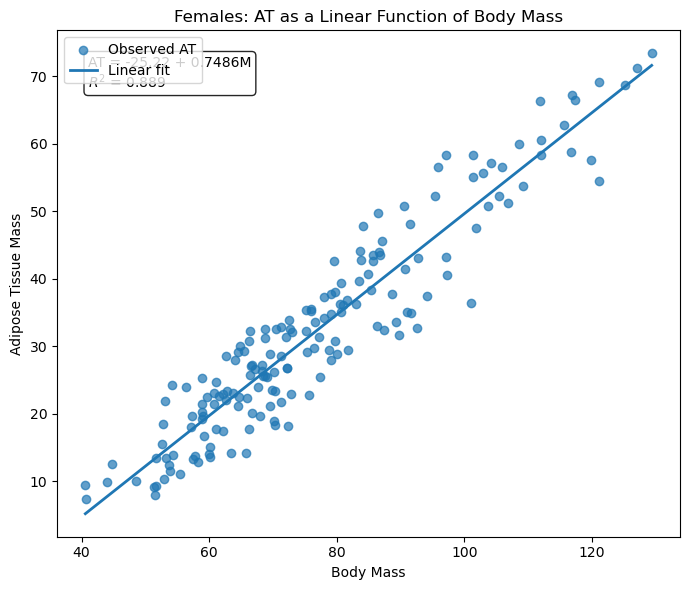

,organ_col,organ,mean_weight,sd_weight,min_weight,max_weight
0,Brain,Brain,0.228719,0.027632,0.170035,0.303444
1,Liver,Liver,0.196100,0.003689,0.184244,0.202372
2,SM,Skeletal Muscle,0.184339,0.001865,0.177172,0.186496
3,AT,Adipose Tissue,0.091919,0.028864,0.021081,0.158299
4,Residual,Remaining Mass,0.084773,0.008539,0.066173,0.107105
5,Kidney,Kidneys,0.080762,0.000331,0.079082,0.081030
6,heart,Heart,0.069544,0.003478,0.060341,0.077005
7,Bone,Bone,0.033339,0.001733,0.029241,0.037355
8,Skin,Skin,0.028949,0.000270,0.028081,0.029207
9,Spleen,Spleen,0.001556,0.000226,0.001057,0.002116


Sum of mean linear-AT model weights:
1.0


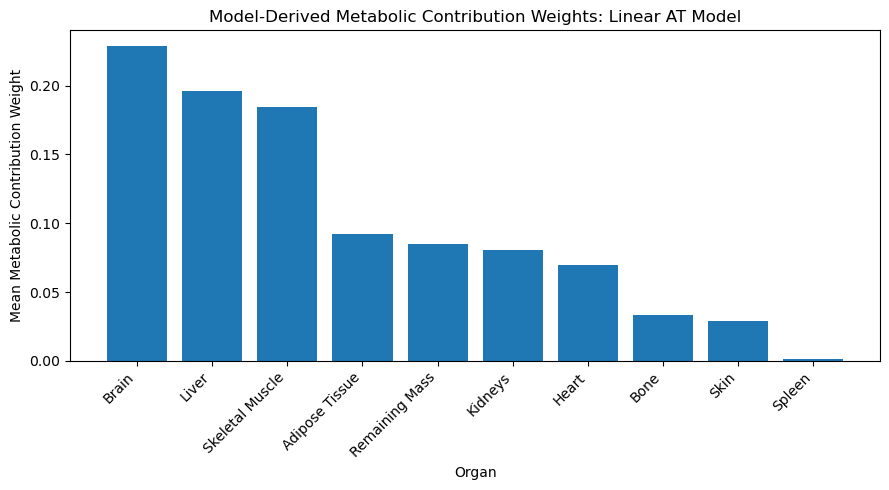

,Estimate,Beta
0,Direct REE power law,0.541631
1,Organ model: all power laws,0.535460
2,Organ model: linear AT,0.529888


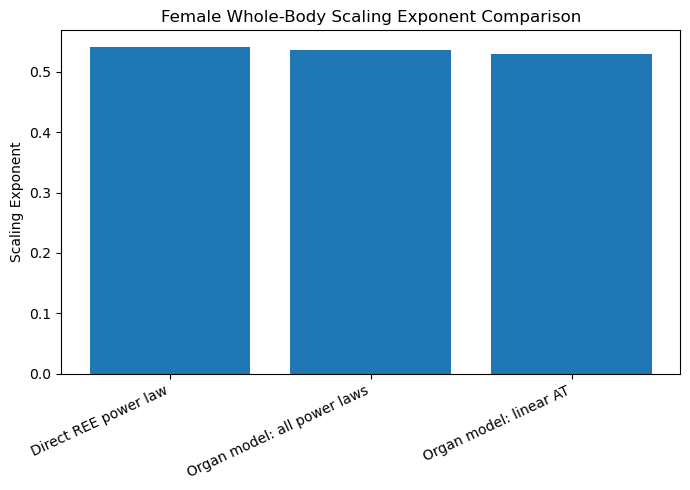

Beta comparison
Direct REE power law: 0.5416
Organ model: all power laws: 0.5355
Organ model: linear AT: 0.5299

At mean body weight:
Mean M = 76.70
Direct REE beta = 0.5416
Power-law organ beta at mean M = 0.5371
Linear-AT organ beta at mean M = 0.5329

REE prediction comparison
Mean measured REE = 1472.72
Mean predicted REE, all power laws = 1513.24
Mean predicted REE, linear AT = 1514.50
Mean difference measured - predicted, all power laws = -40.52
Mean difference measured - predicted, linear AT = -41.78


In [54]:
# ======================================================
# Linear AT sensitivity analysis
#
# 1. Fit AT = alpha_0 + alpha_AT * M
# 2. Plot AT vs body mass with regression equation and R²
# 3. Compute mixed-model weights
# 4. Compare direct REE beta, all-power-law beta, and linear-AT beta
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# ------------------------------------------------------
# Build clean dataframe
# ------------------------------------------------------

linear_at_df = organ_df[[weight_col, ree_col] + organ_cols].copy()

for col in [weight_col, ree_col] + organ_cols:
    linear_at_df[col] = pd.to_numeric(
        linear_at_df[col],
        errors="coerce"
    )

linear_at_df = linear_at_df.replace(
    [np.inf, -np.inf],
    np.nan
)

linear_at_df = linear_at_df.dropna()

linear_at_df = linear_at_df[
    (linear_at_df[weight_col] > 0)
    & (linear_at_df[ree_col] > 0)
].copy()

for organ in organ_cols:
    linear_at_df = linear_at_df[
        linear_at_df[organ] > 0
    ].copy()

# ------------------------------------------------------
# 1. Fit linear AT model
# AT = alpha_0 + alpha_AT * M
# ------------------------------------------------------

X_at = sm.add_constant(
    linear_at_df[weight_col]
)

y_at = linear_at_df["AT"]

at_linear_model = sm.OLS(
    y_at,
    X_at
).fit()

alpha_0 = at_linear_model.params["const"]
alpha_AT = at_linear_model.params[weight_col]

linear_at_df["AT_pred_linear"] = (
    alpha_0
    + alpha_AT * linear_at_df[weight_col]
)

print(at_linear_model.summary())

print("\nLinear AT model:")
print(f"AT = {alpha_0:.6f} + {alpha_AT:.6f} M")
print(f"R^2 = {at_linear_model.rsquared:.6f}")

# ------------------------------------------------------
# 2. Plot AT vs mass with fitted line
# ------------------------------------------------------

plt.figure(figsize=(7, 6))

plt.scatter(
    linear_at_df[weight_col],
    linear_at_df["AT"],
    alpha=0.7,
    label="Observed AT"
)

plot_temp = linear_at_df.sort_values(weight_col)

plt.plot(
    plot_temp[weight_col],
    plot_temp["AT_pred_linear"],
    linewidth=2,
    label="Linear fit"
)

eq_text = (
    f"AT = {alpha_0:.2f} + {alpha_AT:.4f}M\n"
    f"$R^2$ = {at_linear_model.rsquared:.3f}"
)

plt.text(
    0.05,
    0.95,
    eq_text,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        alpha=0.85
    )
)

plt.xlabel("Body Mass")
plt.ylabel("Adipose Tissue Mass")
plt.title("Females: AT as a Linear Function of Body Mass")

plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------
# 3. Compute all-power-law effective beta
# beta_eff(M) = sum_i K_i alpha_i beta_i M^beta_i
#               ----------------------------------------
#               sum_i K_i alpha_i M^beta_i
# ------------------------------------------------------

linear_at_df["REE_pred_powerlaw_organs"] = 0.0

numerator_power = 0.0
denominator_power = 0.0

for organ in organ_cols:

    row = summary_table[
        summary_table["organ"] == organ
    ]

    if row.empty:
        raise ValueError(
            f"{organ} not found in summary_table. "
            "summary_table must contain raw organ column names."
        )

    alpha_i = row["alpha"].iloc[0]
    beta_i = row["beta"].iloc[0]
    K_i = elia_k[organ]

    term = (
        K_i
        * alpha_i
        * linear_at_df[weight_col] ** beta_i
    )

    linear_at_df[f"{organ}_REE_power"] = term
    linear_at_df["REE_pred_powerlaw_organs"] += term

    numerator_power += beta_i * term
    denominator_power += term

linear_at_df["beta_eff_powerlaw_organs"] = (
    numerator_power
    / denominator_power
)

# ------------------------------------------------------
# 4. Compute mixed linear-AT effective beta
#
# REE = K_AT(alpha_0 + alpha_AT M)
#       + sum_{i != AT} K_i alpha_i M^beta_i
#
# beta_eff(M)
# = [K_AT alpha_AT M + sum_{i != AT} K_i alpha_i beta_i M^beta_i]
#   ----------------------------------------------------------------
#   [K_AT(alpha_0 + alpha_AT M) + sum_{i != AT} K_i alpha_i M^beta_i]
# ------------------------------------------------------

linear_at_df["REE_pred_linear_AT"] = 0.0

numerator_linear_at = 0.0
denominator_linear_at = 0.0

for organ in organ_cols:

    row = summary_table[
        summary_table["organ"] == organ
    ]

    if row.empty:
        raise ValueError(
            f"{organ} not found in summary_table."
        )

    K_i = elia_k[organ]

    if organ == "AT":

        denominator_term = (
            K_i
            * (alpha_0 + alpha_AT * linear_at_df[weight_col])
        )

        numerator_term = (
            K_i
            * alpha_AT
            * linear_at_df[weight_col]
        )

    else:

        alpha_i = row["alpha"].iloc[0]
        beta_i = row["beta"].iloc[0]

        denominator_term = (
            K_i
            * alpha_i
            * linear_at_df[weight_col] ** beta_i
        )

        numerator_term = (
            beta_i
            * denominator_term
        )

    linear_at_df[f"{organ}_REE_linear_AT"] = denominator_term
    linear_at_df["REE_pred_linear_AT"] += denominator_term

    numerator_linear_at += numerator_term
    denominator_linear_at += denominator_term

linear_at_df["beta_eff_linear_AT"] = (
    numerator_linear_at
    / denominator_linear_at
)

# ------------------------------------------------------
# 5. Mixed-model weights
# w_i(M) = contribution_i / total predicted REE
# ------------------------------------------------------

mixed_weight_rows = []

for organ in organ_cols:

    weight_col_name = f"{organ}_w_linear_AT"

    linear_at_df[weight_col_name] = (
        linear_at_df[f"{organ}_REE_linear_AT"]
        / linear_at_df["REE_pred_linear_AT"]
    )

    mixed_weight_rows.append({
        "organ_col": organ,
        "organ": organ_name_map.get(organ, organ),
        "mean_weight": linear_at_df[weight_col_name].mean(),
        "sd_weight": linear_at_df[weight_col_name].std(ddof=1),
        "min_weight": linear_at_df[weight_col_name].min(),
        "max_weight": linear_at_df[weight_col_name].max()
    })

mean_linear_at_weights = pd.DataFrame(mixed_weight_rows)

mean_linear_at_weights = mean_linear_at_weights.sort_values(
    "mean_weight",
    ascending=False
).reset_index(drop=True)

display(mean_linear_at_weights)

print("Sum of mean linear-AT model weights:")
print(mean_linear_at_weights["mean_weight"].sum())

plt.figure(figsize=(9, 5))

plt.bar(
    mean_linear_at_weights["organ"],
    mean_linear_at_weights["mean_weight"]
)

plt.ylabel("Mean Metabolic Contribution Weight")
plt.xlabel("Organ")
plt.title("Model-Derived Metabolic Contribution Weights: Linear AT Model")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ------------------------------------------------------
# 6. Beta comparison
# ------------------------------------------------------

beta_comparison = pd.DataFrame({
    "Estimate": [
        "Direct REE power law",
        "Organ model: all power laws",
        "Organ model: linear AT"
    ],
    "Beta": [
        beta_REE_direct,
        linear_at_df["beta_eff_powerlaw_organs"].mean(),
        linear_at_df["beta_eff_linear_AT"].mean()
    ]
})

display(beta_comparison)

plt.figure(figsize=(7, 5))

plt.bar(
    beta_comparison["Estimate"],
    beta_comparison["Beta"]
)

plt.ylabel("Scaling Exponent")
plt.xlabel("")
plt.title("Female Whole-Body Scaling Exponent Comparison")

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

print("Beta comparison")

for _, row in beta_comparison.iterrows():
    print(f"{row['Estimate']}: {row['Beta']:.4f}")

print("\nAt mean body weight:")

mean_M = linear_at_df[weight_col].mean()

sorted_df = linear_at_df.sort_values(weight_col)

beta_power_at_mean = np.interp(
    mean_M,
    sorted_df[weight_col],
    sorted_df["beta_eff_powerlaw_organs"]
)

beta_linear_at_at_mean = np.interp(
    mean_M,
    sorted_df[weight_col],
    sorted_df["beta_eff_linear_AT"]
)

print(f"Mean M = {mean_M:.2f}")
print(f"Direct REE beta = {beta_REE_direct:.4f}")
print(f"Power-law organ beta at mean M = {beta_power_at_mean:.4f}")
print(f"Linear-AT organ beta at mean M = {beta_linear_at_at_mean:.4f}")

# ------------------------------------------------------
# 7. REE prediction comparison
# ------------------------------------------------------

print("\nREE prediction comparison")
print(f"Mean measured REE = {linear_at_df[ree_col].mean():.2f}")
print(f"Mean predicted REE, all power laws = {linear_at_df['REE_pred_powerlaw_organs'].mean():.2f}")
print(f"Mean predicted REE, linear AT = {linear_at_df['REE_pred_linear_AT'].mean():.2f}")
print(
    "Mean difference measured - predicted, all power laws = "
    f"{(linear_at_df[ree_col] - linear_at_df['REE_pred_powerlaw_organs']).mean():.2f}"
)
print(
    "Mean difference measured - predicted, linear AT = "
    f"{(linear_at_df[ree_col] - linear_at_df['REE_pred_linear_AT']).mean():.2f}"
)

### 31. Bar plot of weights when AT is linear.

,Organ,Mean Weight
0,Brain,0.228719
1,Liver,0.196100
2,Skeletal Muscle,0.184339
3,Adipose Tissue,0.091919
4,Remaining Mass,0.084773
5,Kidneys,0.080762
6,Heart,0.069544
7,Bone,0.033339
8,Skin,0.028949
9,Spleen,0.001556


Sum of mean mixed-model weights:
1.0


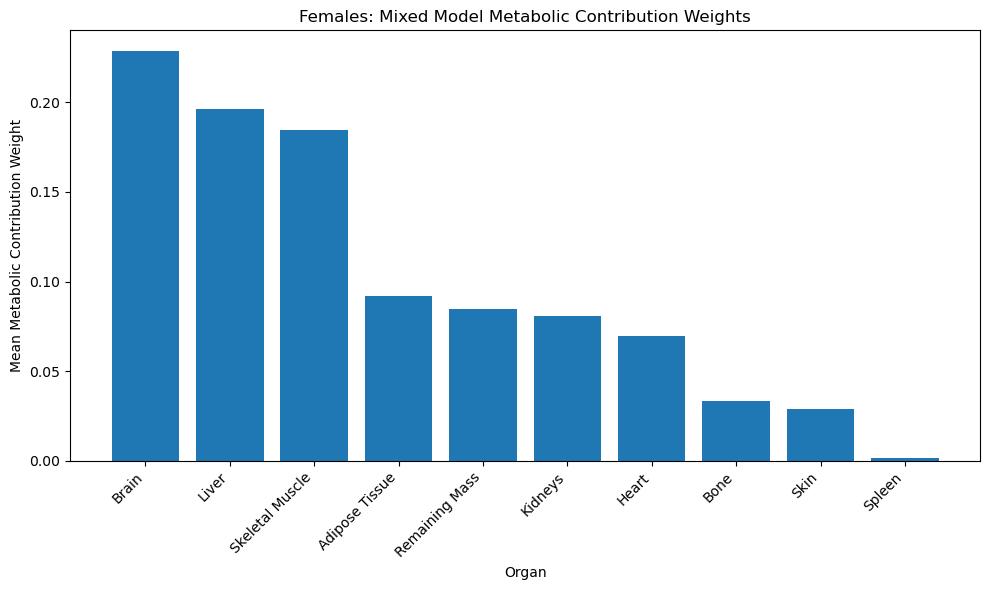

In [55]:
# ======================================================
# Mixed-model metabolic contribution weights
# AT linear; all other organs power laws
# ======================================================

mixed_weight_df = linear_at_df[[weight_col] + organ_cols].copy()

mixed_weight_df["REE_total_mixed"] = 0.0

for organ in organ_cols:

    K_i = elia_k[organ]

    if organ == "AT":

        term = (
            K_i
            * (alpha_0 + alpha_AT * mixed_weight_df[weight_col])
        )

    else:

        row = summary_table[
            summary_table["organ"] == organ
        ]

        if row.empty:
            raise ValueError(f"{organ} not found in summary_table.")

        alpha_i = row["alpha"].iloc[0]
        beta_i = row["beta"].iloc[0]

        term = (
            K_i
            * alpha_i
            * mixed_weight_df[weight_col] ** beta_i
        )

    mixed_weight_df[f"{organ}_REE_term_mixed"] = term
    mixed_weight_df["REE_total_mixed"] += term


# ------------------------------------------------------
# Compute mixed-model weights
# ------------------------------------------------------

for organ in organ_cols:
    mixed_weight_df[f"{organ}_weight_mixed"] = (
        mixed_weight_df[f"{organ}_REE_term_mixed"]
        / mixed_weight_df["REE_total_mixed"]
    )


# ------------------------------------------------------
# Summary table
# ------------------------------------------------------

weights_summary = pd.DataFrame({
    "Organ": [
        organ_name_map.get(organ, organ)
        for organ in organ_cols
    ],
    "Mean Weight": [
        mixed_weight_df[f"{organ}_weight_mixed"].mean()
        for organ in organ_cols
    ]
})

weights_summary = weights_summary.sort_values(
    "Mean Weight",
    ascending=False
).reset_index(drop=True)

display(weights_summary)

print("Sum of mean mixed-model weights:")
print(weights_summary["Mean Weight"].sum())


# ------------------------------------------------------
# Plot
# ------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    weights_summary["Organ"],
    weights_summary["Mean Weight"]
)

plt.ylabel("Mean Metabolic Contribution Weight")
plt.xlabel("Organ")
plt.title("Females: Mixed Model Metabolic Contribution Weights")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Participant characteristics in reference dataset used for analysis.

In [56]:
# ======================================================
# Participant characteristics table
# Complete-case reference dataset used in analysis
# Values reported as mean (SD)
# ======================================================

def mean_sd(series):
    series = pd.to_numeric(series, errors="coerce").dropna()
    return f"{series.mean():.2f} ({series.std(ddof=1):.2f})"

# ------------------------------------------------------
# Find demographic columns robustly
# ------------------------------------------------------

col_lookup = {
    col.lower().strip(): col
    for col in df.columns
}

age_col = col_lookup.get("age")
height_col = col_lookup.get("height")

print("Age column:", age_col)
print("Height column:", height_col)

# ------------------------------------------------------
# Build complete-case reference dataset
# Uses the same required variables as the main analysis
# ------------------------------------------------------

reference_cols = [weight_col, ree_col] + organ_cols

if age_col is not None:
    reference_cols.append(age_col)

if height_col is not None:
    reference_cols.append(height_col)

reference_df = df[reference_cols].copy()

for col in reference_cols:
    reference_df[col] = pd.to_numeric(reference_df[col], errors="coerce")

reference_df = (
    reference_df
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

reference_df = reference_df[
    (reference_df[weight_col] > 0)
    & (reference_df[ree_col] > 0)
].copy()

for organ in organ_cols:
    reference_df = reference_df[
        reference_df[organ] > 0
    ].copy()

# ------------------------------------------------------
# Derived variables
# Height is in meters in these files
# ------------------------------------------------------

if height_col is not None:
    reference_df["BMI"] = (
        reference_df[weight_col]
        / reference_df[height_col] ** 2
    )

reference_df["Total organ mass"] = reference_df[organ_cols].sum(axis=1)

# ------------------------------------------------------
# Characteristics table
# ------------------------------------------------------

sex_label = "Females"  # change to "Males" in male notebook

rows = [
    ("n", str(len(reference_df))),
    ("Age, years", mean_sd(reference_df[age_col]) if age_col is not None else "Column not found"),
    ("Height, m", mean_sd(reference_df[height_col]) if height_col is not None else "Column not found"),
    ("Body mass, kg", mean_sd(reference_df[weight_col])),
    ("BMI, kg/m²", mean_sd(reference_df["BMI"]) if "BMI" in reference_df.columns else "Column not found"),
    ("Measured RMR, kcal/day", mean_sd(reference_df[ree_col])),
    ("Adipose tissue mass, kg", mean_sd(reference_df["AT"])),
    ("Skeletal muscle mass, kg", mean_sd(reference_df["SM"])),
    ("Total modeled tissue mass, kg", mean_sd(reference_df["Total organ mass"]))
]

reference_characteristics_table = pd.DataFrame(
    rows,
    columns=["Characteristic", sex_label]
)

display(reference_characteristics_table)

Age column: Age
Height column: Height


,Characteristic,Females
0,n,173
1,"Age, years",40.07 (15.34)
2,"Height, m",1.67 (0.07)
3,"Body mass, kg",76.70 (19.10)
4,"BMI, kg/m²",27.42 (6.03)
5,"Measured RMR, kcal/day",1472.72 (233.29)
6,"Adipose tissue mass, kg",32.20 (15.16)
7,"Skeletal muscle mass, kg",21.64 (3.92)
8,"Total modeled tissue mass, kg",76.70 (19.10)


### Sensitivity Analysis Using Wang-Adjusted Tissue-Specific Metabolic Rates

The primary analysis used the tissue-specific metabolic rate coefficients (\(K_i\)) proposed by Elia, which express resting energy expenditure as

$$
REE(M)
=
\sum_i K_i Y_i(M),
$$

where $Y_i(M)$ is the mass of organ or tissue compartment $i$ and $K_i$ is its specific metabolic rate (kcal/kg/day).

Although Elia's coefficients are widely used, Wang et al. later reported refined estimates based on organ-level analyses of resting energy expenditure. To evaluate whether the conclusions of the present study depend on the choice of $K_i$, we performed a sensitivity analysis using sex-specific midpoint values derived from the confidence intervals reported by Wang and colleagues.

For each set of metabolic rate coefficients, the predicted resting energy expenditure was reconstructed as

$$
REE(M)
=
\sum_i K_i \alpha_i M^{\beta_i},
$$

where $\alpha_i$ and $\beta_i$ are the organ-specific scaling parameters estimated previously.

The corresponding effective whole-body scaling exponent was then computed using the theoretical result developed in this study:

$$
\beta_{\text{eff}}(M)
=
\frac{
\sum_i
K_i \alpha_i \beta_i M^{\beta_i}
}{
\sum_i
K_i \alpha_i M^{\beta_i}
}.
$$

This quantity represents the metabolically weighted average of the organ-specific scaling exponents and determines the local scaling behavior of whole-body resting energy expenditure.

The analysis compares:

1. Elia's original tissue-specific metabolic rate coefficients.
2. Wang-adjusted sex-specific metabolic rate coefficients.

For each coefficient set, the code:

- Reconstructs organ-specific contributions to resting energy expenditure.
- Computes the effective whole-body scaling exponent $\beta_{\text{eff}}(M)$.
- Calculates mean organ metabolic weights

$$
w_i(M)
=
\frac{
K_i \alpha_i M^{\beta_i}
}{
\sum_j K_j \alpha_j M^{\beta_j}
},
$$

which represent the proportional contribution of each organ to total resting energy expenditure.
- Quantifies the change in the aggregate scaling exponent relative to the Elia model.
- Produces tables and figures summarizing the sensitivity of the results to the choice of $K_i$.

Because the theoretical framework depends on the relative metabolic weighting of organs rather than any single tissue-specific metabolic rate coefficient, only modest changes in the effective scaling exponent would indicate that the mechanistic conclusions are robust to alternative estimates of organ energetics.

,Sex,Ki set,Mean effective beta,SD effective beta,Mean predicted REE,Change in beta vs Elia,Percent change in beta vs Elia
0,Female,Elia,0.535460,0.061375,1513.242506,0.000000,0.000000
1,Female,Wang sex-specific midpoint,0.535103,0.061898,1491.531879,-0.000357,-0.066678


,organ,mean_REE_weight_Elia,mean_REE_weight_Wang,difference_Wang_minus_Elia
0,Brain,0.225336,0.227187,0.001851
1,Liver,0.196727,0.198094,0.001367
2,Skeletal Muscle,0.184711,0.185958,0.001247
3,Adipose Tissue,0.094924,0.095877,0.000954
4,Remaining Mass,0.083736,0.083893,0.000157
5,Kidneys,0.080847,0.077364,-0.003484
6,Heart,0.070052,0.067034,-0.003019
7,Bone,0.033140,0.033623,0.000482
8,Skin,0.028939,0.029360,0.000421
9,Spleen,0.001587,0.001610,0.000023


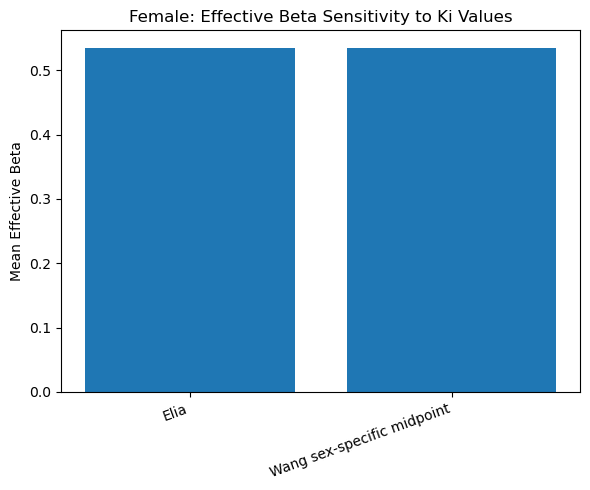


Bottom line:
Female: Wang midpoint Ki values changed mean effective beta by -0.000357 (-0.07%).


In [57]:
 # ======================================================
# Sensitivity analysis:
# Effective beta using Wang-adjusted sex-specific Ki values
#
# Compares Elia Ki values with sex-specific midpoint values
# from Wang et al. confidence intervals reported in Muller et al. 2013.
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------
# Identify sex from column naming
# ------------------------------------------------------

is_female = "heart" in organ_cols
sex_label = "Female" if is_female else "Male"

# ------------------------------------------------------
# Elia Ki values, kcal/kg/day
# NOTE:
# Bone, skin, spleen are retained as 12 because the Wang/Elia
# 7-compartment summaries treat these within residual/remaining mass.
# ------------------------------------------------------

elia_k_sensitivity = {
    "AT": 4.5,
    "SM": 13,
    "Bone": 12,
    "Liver": 200,
    "Kidney": 440,
    "Spleen": 12,
    "Brain": 240,
    "Skin": 12,
    "Residual": 12
}

if is_female:
    elia_k_sensitivity["heart"] = 440
else:
    elia_k_sensitivity["Heart"] = 440

# ------------------------------------------------------
# Wang sex-specific midpoint Ki values from reported 95% CIs
#
# Male CIs:
# AT 2.83-5.71, SM 11.9-13.5, Liver 179-213,
# Brain 216-253, Heart 342-481, Kidney 325-484,
# Residual 10.8-12.6
#
# Female CIs:
# AT 3.82-5.14, SM 12.0-13.8, Liver 183-214,
# Brain 223-254, Heart 342-488, Kidney 339-491,
# Residual 10.9-12.8
# ------------------------------------------------------

if is_female:

    wang_k_sensitivity = {
        "AT": (3.82 + 5.14) / 2,
        "SM": (12.0 + 13.8) / 2,
        "Bone": 12,
        "Liver": (183 + 214) / 2,
        "heart": (342 + 488) / 2,
        "Kidney": (339 + 491) / 2,
        "Spleen": 12,
        "Brain": (223 + 254) / 2,
        "Skin": 12,
        "Residual": (10.9 + 12.8) / 2
    }

else:

    wang_k_sensitivity = {
        "AT": (2.83 + 5.71) / 2,
        "SM": (11.9 + 13.5) / 2,
        "Bone": 12,
        "Liver": (179 + 213) / 2,
        "Heart": (342 + 481) / 2,
        "Kidney": (325 + 484) / 2,
        "Spleen": 12,
        "Brain": (216 + 253) / 2,
        "Skin": 12,
        "Residual": (10.8 + 12.6) / 2
    }

# ------------------------------------------------------
# Helper function: compute effective beta
# beta_eff(M) = sum_i Ki alpha_i beta_i M^beta_i /
#               sum_i Ki alpha_i M^beta_i
# ------------------------------------------------------

def compute_effective_beta_from_k(k_dict, label):

    beta_df = organ_df[[weight_col] + organ_cols].copy()

    for col in [weight_col] + organ_cols:
        beta_df[col] = pd.to_numeric(beta_df[col], errors="coerce")

    beta_df = beta_df.replace([np.inf, -np.inf], np.nan).dropna()
    beta_df = beta_df[beta_df[weight_col] > 0].copy()

    numerator = 0.0
    denominator = 0.0

    component_rows = []

    for organ in organ_cols:

        row = summary_table[summary_table["organ"] == organ]

        if row.empty:
            raise ValueError(f"{organ} not found in summary_table.")

        alpha_i = row["alpha"].iloc[0]
        beta_i = row["beta"].iloc[0]
        K_i = k_dict[organ]

        contribution = (
            K_i
            * alpha_i
            * beta_df[weight_col] ** beta_i
        )

        numerator += beta_i * contribution
        denominator += contribution

        beta_df[f"{organ}_{label}_REE_contribution"] = contribution

        component_rows.append({
            "organ": organ_name_map.get(organ, organ),
            "K": K_i,
            "beta_i": beta_i,
            "mean_REE_weight": contribution.mean()
        })

    beta_df[f"beta_eff_{label}"] = numerator / denominator
    beta_df[f"REE_pred_{label}"] = denominator

    component_table = pd.DataFrame(component_rows)
    component_table["mean_REE_weight"] = (
        component_table["mean_REE_weight"]
        / component_table["mean_REE_weight"].sum()
    )

    component_table = component_table.sort_values(
        "mean_REE_weight",
        ascending=False
    ).reset_index(drop=True)

    return beta_df, component_table

# ------------------------------------------------------
# Run Elia vs Wang sensitivity analysis
# ------------------------------------------------------

elia_beta_df, elia_component_table = compute_effective_beta_from_k(
    elia_k_sensitivity,
    "Elia"
)

wang_beta_df, wang_component_table = compute_effective_beta_from_k(
    wang_k_sensitivity,
    "Wang"
)

# ------------------------------------------------------
# Summarize effective beta
# ------------------------------------------------------

beta_sensitivity = pd.DataFrame({
    "Sex": [sex_label, sex_label],
    "Ki set": ["Elia", "Wang sex-specific midpoint"],
    "Mean effective beta": [
        elia_beta_df["beta_eff_Elia"].mean(),
        wang_beta_df["beta_eff_Wang"].mean()
    ],
    "SD effective beta": [
        elia_beta_df["beta_eff_Elia"].std(ddof=1),
        wang_beta_df["beta_eff_Wang"].std(ddof=1)
    ],
    "Mean predicted REE": [
        elia_beta_df["REE_pred_Elia"].mean(),
        wang_beta_df["REE_pred_Wang"].mean()
    ]
})

beta_sensitivity["Change in beta vs Elia"] = (
    beta_sensitivity["Mean effective beta"]
    - beta_sensitivity.loc[
        beta_sensitivity["Ki set"] == "Elia",
        "Mean effective beta"
    ].iloc[0]
)

beta_sensitivity["Percent change in beta vs Elia"] = (
    100
    * beta_sensitivity["Change in beta vs Elia"]
    / beta_sensitivity.loc[
        beta_sensitivity["Ki set"] == "Elia",
        "Mean effective beta"
    ].iloc[0]
)

display(beta_sensitivity)

# ------------------------------------------------------
# Compare organ weights
# ------------------------------------------------------

weight_compare = elia_component_table[["organ", "mean_REE_weight"]].merge(
    wang_component_table[["organ", "mean_REE_weight"]],
    on="organ",
    suffixes=("_Elia", "_Wang")
)

weight_compare["difference_Wang_minus_Elia"] = (
    weight_compare["mean_REE_weight_Wang"]
    - weight_compare["mean_REE_weight_Elia"]
)

weight_compare = weight_compare.sort_values(
    "mean_REE_weight_Elia",
    ascending=False
).reset_index(drop=True)

display(weight_compare)

# ------------------------------------------------------
# Save output tables
# ------------------------------------------------------

beta_sensitivity.to_csv(
    f"{sex_label}_Ki_sensitivity_effective_beta.csv",
    index=False
)

weight_compare.to_csv(
    f"{sex_label}_Ki_sensitivity_organ_weights.csv",
    index=False
)

# ------------------------------------------------------
# Plot beta comparison
# ------------------------------------------------------

plt.figure(figsize=(6, 5))

plt.bar(
    beta_sensitivity["Ki set"],
    beta_sensitivity["Mean effective beta"]
)

plt.ylabel("Mean Effective Beta")
plt.title(f"{sex_label}: Effective Beta Sensitivity to Ki Values")

plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plt.savefig(
    f"{sex_label}_Ki_sensitivity_effective_beta.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nBottom line:")
print(
    f"{sex_label}: Wang midpoint Ki values changed mean effective beta by "
    f"{beta_sensitivity.loc[1, 'Change in beta vs Elia']:.6f} "
    f"({beta_sensitivity.loc[1, 'Percent change in beta vs Elia']:.2f}%)."
)